# On the Information Bottleneck Theory of Deep Learning

### A complete reproduction, implemented from scratch

> A. M. Saxe, Y. Bansal, J. Dapello, M. Advani, A. Kolchinsky, B. D. Tracey, D. D. Cox,
> *On the information bottleneck theory of deep learning*, **ICLR 2018** / **J. Stat. Mech.**
> (2019) 124020.

*Course project — Information Theory and Inference.*

---

## The story this paper is answering

Shwartz-Ziv & Tishby (2017) trained deep networks and plotted, for each hidden layer, the
pair

$$\big(\,I(X;T),\ I(T;Y)\,\big)$$

as training proceeded — the **information plane**. $X$ is the input, $Y$ the label, $T$ the
layer's representation. They reported a striking picture: every layer first moves **right
and up** (it becomes more informative about both input and label — *fitting*), and then
turns around and moves **left** (it becomes *less* informative about the input while keeping
the label information — *compression*).

Three claims were built on that picture:

| # | claim |
|---|---|
| **1** | Deep learning has **two distinct phases**: a short fitting phase, then a long compression phase. |
| **2** | **Compression causes generalisation** — the network generalises *because* it throws input information away. |
| **3** | Compression is **caused by the stochastic noise of SGD** (a "diffusion" phase in weight space). |

If true, this is a theory of why deep learning works, expressed entirely in bits.

## What Saxe et al. show, and what this notebook reproduces

None of the three claims holds in general. And the reason is not a bug in anyone's code —
it is definitional:

> For a **deterministic** network with **continuous** activations, $T = f(X)$ is a
> deterministic function of $X$. If $X$ is continuous, $h(T\mid X) = -\infty$ and
> $$I(X;T) = \infty$$
> at *every* point in training. If $X$ is discrete, $I(X;T) = H(X)$ — a **constant**.
> Either way there is nothing to plot.

Every finite number ever plotted in an information plane therefore comes from an **added
assumption** — binning the activations, or adding noise to them. The trajectory reports on
that assumption at least as much as it reports on the network. Most of this notebook is
about making that concrete and measurable.

## Roadmap

| § | question | experiment | verdict |
|---|---|---|---|
| 1 | What is actually being measured? | implement the binning estimator, eqs (1)–(4) | $I(X;T) = H(T)$: it is an *entropy of a discretisation* |
| 2 | Why does tanh appear to compress? | one weight, one neuron, solved **exactly** | saturation + binning, nothing to do with learning |
| 3 | Does the original result replicate? | 12–10–7–5–4–3–2 net, `tanh` vs `relu` | replicates for tanh; **vanishes** for ReLU → **claim 1 fails** |
| 4 | Does the measurement decide the answer? | same run, three binning conventions, then a different estimator | conclusion flips → the effect is not a property of the network |
| 5 | Is it an estimator artefact? | deep **linear** nets: exact closed-form MI | no compression at all; and compression ⊥ generalisation → **claim 2 fails** |
| 6 | Is SGD's noise the cause? | full-batch GD (no noise whatsoever) | compresses *more* than SGD → **claim 3 fails** |
| 7 | When compression *is* real, is it a second phase? | task-relevant / task-irrelevant split | real, but **simultaneous** with fitting |

**Everything below is implemented in this notebook** — the estimators, the models, the
training loops. Nothing is imported from a project library. The only external input is the
authors' own dataset file, `reference/var_u.mat`.

> **Runtime.** From an empty cache the notebook trains 5 networks and takes about 6
> minutes. Results are cached to `final/cache/`, so every later run is seconds.

## 0. Setup

Imports, plotting style, and two utilities used throughout: a disk cache, and the
information-plane plot itself.

In [1]:
import gzip, pickle, time
from pathlib import Path

import numpy as np
import scipy.io as sio
from scipy.stats import norm
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import torch
import torch.nn as nn

# ---- project paths ------------------------------------------------------- #
ROOT = Path.cwd()
while not (ROOT / "reference" / "var_u.mat").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
CACHE = ROOT / "final" / "cache";   CACHE.mkdir(parents=True, exist_ok=True)
FIGDIR = ROOT / "final" / "figures"; FIGDIR.mkdir(parents=True, exist_ok=True)

torch.set_num_threads(4)

# ---- plot style ---------------------------------------------------------- #
mpl.rcParams.update({
    "figure.dpi": 110, "savefig.dpi": 180, "savefig.bbox": "tight",
    "font.size": 10, "axes.titlesize": 11, "axes.grid": True,
    "grid.alpha": 0.25, "grid.linewidth": 0.5,
    "axes.spines.top": False, "axes.spines.right": False,
    "legend.frameon": False, "legend.fontsize": 8,
    "lines.linewidth": 1.6, "figure.facecolor": "white",
})

# ---- disk cache: every expensive result is stored, so re-running is instant -- #
def cached(name, fn, force=False):
    """Return fn(), memoised to final/cache/<name>.pkl.gz."""
    path = CACHE / f"{name}.pkl.gz"
    if path.exists() and not force:
        with gzip.open(path, "rb") as fh:
            return pickle.load(fh)
    print(f"  computing '{name}' ...", flush=True)
    t0 = time.time()
    obj = fn()
    with gzip.open(path, "wb", compresslevel=4) as fh:
        pickle.dump(obj, fh, protocol=pickle.HIGHEST_PROTOCOL)
    print(f"  done in {time.time() - t0:.0f}s", flush=True)
    return obj

# ---- the signature plot -------------------------------------------------- #
def plot_plane(epochs, I_XT, I_TY, ax=None, title="", layer_names=None,
               colorbar=True, annotate=False):
    """Information plane: one dot per (layer, checkpoint), coloured by epoch.

    Layers at the same epoch are joined by a faint line, so the layer ordering
    is visible: the first hidden layer sits far RIGHT (it knows most about X),
    the output layer far LEFT.  Movement right/up = fitting, LEFT = compression.
    """
    I_XT, I_TY, epochs = np.asarray(I_XT), np.asarray(I_TY), np.asarray(epochs)
    if ax is None:
        _, ax = plt.subplots(figsize=(4.6, 3.8))
    e = np.where(epochs == 0, 1, epochs)
    norm_ = LogNorm(vmin=max(e.min(), 1), vmax=e.max())
    sm = plt.cm.ScalarMappable(norm=norm_, cmap="viridis")
    step = max(1, len(epochs) // 25)
    for i in range(0, len(epochs), step):
        ax.plot(I_XT[i], I_TY[i], "-", color=sm.to_rgba(e[i]), alpha=0.35, lw=0.5, zorder=1)
    for j in range(I_XT.shape[1]):
        ax.scatter(I_XT[:, j], I_TY[:, j], c=e, cmap="viridis", norm=norm_,
                   s=22, edgecolors="none", zorder=2)
        if annotate and layer_names is not None:
            ax.annotate(layer_names[j], (I_XT[-1, j], I_TY[-1, j]), fontsize=7,
                        color="0.25", textcoords="offset points", xytext=(4, 4))
    ax.set_xlabel(r"$I(X;T)$  [bits]")
    ax.set_ylabel(r"$I(T;Y)$  [bits]")
    ax.set_title(title)
    if colorbar:
        cb = ax.figure.colorbar(sm, ax=ax, pad=0.02)
        cb.set_label("epoch", fontsize=8)
        cb.ax.tick_params(labelsize=7)
    return ax

def plot_layers(epochs, values, ax=None, layer_names=None, ylabel="", title="",
                logy=False, hline=None, hline_label=""):
    """One curve per layer against epoch (log x-axis)."""
    values, epochs = np.asarray(values), np.asarray(epochs)
    if ax is None:
        _, ax = plt.subplots(figsize=(4.6, 3.4))
    colors = plt.get_cmap("plasma")(np.linspace(0.05, 0.85, values.shape[1]))
    x = np.where(epochs == 0, 0.5, epochs)
    for j in range(values.shape[1]):
        ax.plot(x, values[:, j], color=colors[j],
                label=layer_names[j] if layer_names is not None else f"layer {j+1}")
    if hline is not None:
        ax.axhline(hline, ls="--", lw=1.0, color="0.4", label=hline_label or None)
    ax.set_xscale("log")
    if logy:
        ax.set_yscale("log")
    ax.set_xlabel("epoch"); ax.set_ylabel(ylabel); ax.set_title(title)
    ax.legend(ncol=2)
    return ax

def save(fig, name):
    fig.savefig(FIGDIR / f"{name}.png")
    fig.savefig(FIGDIR / f"{name}.pdf")

print("project root :", ROOT)
print("cache        :", CACHE)
print("torch", torch.__version__, "| numpy", np.__version__)

project root : /home/hooman/Desktop/InfoTheory/Project
cache        : /home/hooman/Desktop/InfoTheory/Project/final/cache
torch 2.13.0+cpu | numpy 2.5.1


---

# 1. What the information plane actually measures

## 1.1 The problem, stated precisely

A hidden layer computes $h = f(X)$ — deterministically, with continuous-valued outputs.
Mutual information is

$$I(X;h) = H(h) - H(h \mid X).$$

Because $h$ is a *deterministic function* of $X$, knowing $X$ removes all uncertainty
about $h$:

* if $X$ is **discrete**, $H(h \mid X) = 0$, so $I(X;h) = H(h) = H(X)$ whenever $f$ is
  injective — a **constant**, independent of the weights;
* if $X$ is **continuous**, the differential entropy $h(h \mid X) = -\infty$, so
  $I(X;h) = +\infty$ — for every weight setting, at every epoch.

So the quantity the information plane claims to track is either constant or infinite. It
cannot move. Whatever moves in the published figures is not $I(X;h)$.

## 1.2 What is plotted instead

To get a finite, moving number one defines a new variable $T$ from $h$ by adding an
assumption. Two are used in the literature, and both appear in this notebook:

| assumption | definition | used in |
|---|---|---|
| **binning** | $T = \mathrm{bin}(h)$, discretise each unit into a finite number of levels | §2–§4, §7 |
| **noise** | $T = h + \epsilon$, $\epsilon \sim \mathcal{N}(0,\sigma^2 I)$ | §5, §6 |

Neither is part of the network. Both are choices made by the analyst — and, as §4 shows,
the choice determines the answer.

## 1.3 The binning estimator, eqs (1)–(3)

With $T = \mathrm{bin}(h)$ and $h$ deterministic in $X$, $T$ is a deterministic function of
$X$, so $H(T \mid X) = 0$ and

$$\boxed{\,I(X;T) = H(T) = -\sum_i p_i \log_2 p_i\,}$$

**The x-axis of every information plane is just the entropy of the discretised
representation.** "Compression" means: the layer's activity patterns are collapsing onto
fewer distinct bins. For the label, $Y$ is genuinely discrete, so

$$I(T;Y) = H(T) - \sum_y p(y)\, H(T \mid Y = y)$$

needs no further assumption beyond the binning itself.

Two consequences worth internalising before looking at any figure:

* $I(X;T) \le \log_2 P$ always, where $P$ is the number of input patterns. The estimator's
  **resolution** sets the entire scale of the y-axis.
* Bin finely enough and every input gets its own code, so $I(X;T) = \log_2 P$ forever,
  with no dynamics at all (we do exactly this in §4.2).

Here is the whole estimator — 30 lines.

In [2]:
def entropy_of_rows(codes):
    """Plug-in entropy H(T) in bits of the distribution over discrete rows.

    Every unit is binned separately, but a *layer*'s symbol is the joint bin
    pattern across its units, so rows must be treated as atomic.
    """
    codes = np.ascontiguousarray(codes)
    if codes.ndim == 1:
        codes = codes[:, None]
    _, inverse = np.unique(codes, axis=0, return_inverse=True)
    counts = np.bincount(inverse.ravel())
    p = counts[counts > 0] / counts.sum()
    return float(-(p * np.log2(p)).sum())


def discretize(h, scheme="uniform", n_bins=30, bounds=(-1.0, 1.0)):
    """Map continuous activity to bin indices under one of three conventions.

    "uniform"    equally spaced bins across `bounds`         (paper section 2)
    "net_input"  bins equally spaced in NET INPUT, i.e.
                 edges at tanh(linspace(-50, 50, N))         (paper appendix C)
    "exact"      no binning: reinterpret the float32 bits, so two activities
                 share a symbol only if bit-identical        (paper figure C3)
    """
    if scheme == "uniform":
        edges = np.linspace(bounds[0], bounds[1], n_bins + 1)
    elif scheme == "net_input":
        edges = np.unique(np.tanh(np.linspace(-50.0, 50.0, n_bins + 1)))
    elif scheme == "exact":
        return np.asarray(h, dtype=np.float32).view(np.int32)
    else:
        raise ValueError(scheme)
    return np.digitize(h, edges[1:-1], right=False).astype(np.int32)


def mi_binned(h, y, **kw):
    """Return (I(X;T), I(T;Y)) in bits for one layer.  Paper eqs (1)-(3).

    h : (P, n_units) activity, one row per input pattern -- and the P rows must
        enumerate the whole input distribution, which for this dataset they do.
    y : (P,) integer labels.
    """
    T = discretize(np.asarray(h, dtype=np.float64), **kw)

    H_T = entropy_of_rows(T)                       # = I(X;T), see the markdown
    H_T_given_Y = 0.0
    for c in np.unique(y):
        mask = y == c
        H_T_given_Y += mask.mean() * entropy_of_rows(T[mask])
    return H_T, H_T - H_T_given_Y


def information_plane(acts_per_checkpoint, y, **kw):
    """Apply mi_binned to every layer at every checkpoint -> two (n_ckpt, n_layer) arrays."""
    ixt, ity = [], []
    for acts in acts_per_checkpoint:
        pairs = [mi_binned(a, y, **kw) for a in acts]
        ixt.append([p[0] for p in pairs])
        ity.append([p[1] for p in pairs])
    return np.array(ixt), np.array(ity)

### Validating the estimator

Before trusting any figure, check the implementation against cases whose answers are known
analytically.

In [3]:
rng = np.random.default_rng(0)

# 1. a perfect code: 1024 distinct symbols, uniform -> exactly 10 bits
print(f"H(uniform over 1024 symbols) = {entropy_of_rows(np.arange(1024)[:, None]):.10f}   (exact: 10)")

# 2. a constant representation carries nothing
print(f"H(constant)                  = {abs(entropy_of_rows(np.zeros((4096, 5)))):.10f}   (exact:  0)")

# 3. the ceiling: I(X;T) <= log2(P), whatever the layer does
h_random = rng.uniform(-1, 1, size=(4096, 8))       # 8 units, unrelated to any label
y_random = rng.integers(0, 2, size=4096)            # a label independent of h
ixt, ity = mi_binned(h_random, y_random, n_bins=30, bounds=(-1, 1))
print()
print(f"random 8-unit layer, 30 bins : I(X;T) = {ixt:.3f}  <=  log2(4096) = {np.log2(4096):.1f}   ok")

# 4. ...and a warning that comes with it. h is INDEPENDENT of y here, so the true
#    I(T;Y) is 0 -- but with 8 units at 30 bins every one of the 4096 rows is
#    unique, so T identifies the sample, hence its label, and the plug-in estimate
#    returns H(Y). Full resolution does not mean an accurate estimate; it means a
#    maximally biased one. (Section 4.2 is this same effect on a real network.)
print(f"                               I(T;Y) = {ity:.3f}  vs true value 0, and H(Y) = 1.0")

# 5. finer bins can only ever RAISE I(X;T) -- the estimate is resolution-bound
print()
for nb in (2, 3, 5, 10, 30):
    print(f"   {nb:>4d} bins -> I(X;T) = {mi_binned(h_random, y_random, n_bins=nb)[0]:6.3f} bits")

H(uniform over 1024 symbols) = 10.0000000000   (exact: 10)
H(constant)                  = 0.0000000000   (exact:  0)

random 8-unit layer, 30 bins : I(X;T) = 12.000  <=  log2(4096) = 12.0   ok
                               I(T;Y) = 1.000  vs true value 0, and H(Y) = 1.0

      2 bins -> I(X;T) =  7.950 bits
      3 bins -> I(X;T) = 11.446 bits
      5 bins -> I(X;T) = 11.991 bits
     10 bins -> I(X;T) = 12.000 bits
     30 bins -> I(X;T) = 12.000 bits


The last block is the paper's central complaint in miniature: **the same layer, measured at
different resolutions, has different "information".** Nothing about the network changed
between those five lines.

---

# 2. Why a tanh network appears to compress

**Paper section 2, figure 2.** Before touching a deep network, the mechanism can be
isolated in a model small enough to solve exactly:

$$X \sim \mathcal{N}(0,1), \qquad h = f(w_1 X), \qquad T = \mathrm{bin}(h).$$

One input, one weight, one neuron. There is no "learning" here at all — we simply sweep
$w_1$ by hand and compute $I(T;X) = H(T)$ **exactly**, with no sampling and no estimator
error, from the Gaussian CDF (paper eq. 4):

$$p_i = \Phi\!\Big(\frac{f^{-1}(b_{i+1})}{w_1}\Big) - \Phi\!\Big(\frac{f^{-1}(b_i)}{w_1}\Big).$$

## The prediction

* **tanh** is *double-saturating*: bounded above **and** below. As $w_1$ grows, almost every
  input is pushed into one of the two extreme bins, so $T$ degenerates into a coin flip and
  $H(T) \to 1$ bit. $I(T;X)$ must rise, peak, and **fall**.
* **ReLU** is *single-sided*: bounded below at 0, unbounded above. Half the inputs collapse
  onto the zero bin (contributing at most 1 bit), while the positive half spreads over ever
  more bins as $w_1$ grows. $I(T;X)$ can only **rise**.

The link to training: networks are initialised with **small** weights, and a tanh network
starts life in its linear regime — it *must* grow its weights to compute anything nonlinear
(paper appendix D). Growing them traverses this curve from left to right. **That traversal
is the compression phase.**

In [4]:
def bin_probabilities(w1, activation="tanh", n_bins=30, net_input=False):
    """Exact probability of each bin for h = f(w1 X), X ~ N(0,1).  Paper eq (4).

    Because f is monotone the bin edges can be pulled back through f^-1 and the
    probabilities read off the Gaussian CDF -- no sampling, no estimator error.
    """
    w1 = float(w1)
    if activation == "tanh":
        edges = (np.tanh(np.linspace(-50.0, 50.0, n_bins + 1)) if net_input
                 else np.linspace(-1.0, 1.0, n_bins + 1))
        with np.errstate(divide="ignore", invalid="ignore"):
            cdf = norm.cdf(np.arctanh(edges) / w1)      # f^-1(b) = arctanh(b)
        cdf[0], cdf[-1] = 0.0, 1.0                      # outermost edges: +-inf
        p = np.diff(cdf)
    elif activation == "relu":
        # Unbounded above, so tile fixed-width bins (same width as tanh's) out
        # past the largest activity that has any probability mass.  ALL x <= 0
        # map to h = 0 and therefore land in the first bin.
        width = 2.0 / n_bins
        edges = np.arange(0.0, max(8.0 * abs(w1), 10 * width) + width, width)
        cdf = norm.cdf(edges[1:] / w1)
        p = np.diff(np.concatenate([[0.0], cdf, [1.0]]))
    else:
        raise ValueError(activation)
    return p[p > 0]


def mi_minimal(w1, **kw):
    """I(T;X) = H(T) for the minimal model, exactly."""
    p = bin_probabilities(w1, **kw)
    return float(-(p * np.log2(p)).sum())

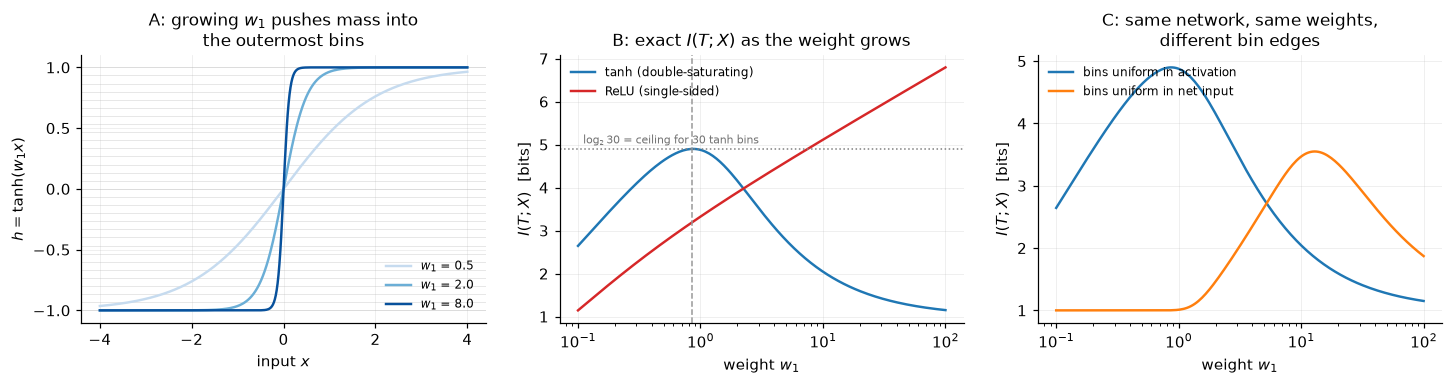

curve                                start    peak   final   compression
------------------------------------------------------------------------
tanh, bins uniform in activation      2.64    4.90    1.15          3.75
ReLU, bins uniform in activation      1.14    6.80    6.80          0.00
tanh, bins uniform in net input       1.00    3.55    1.87          1.68

tanh peaks at w1 = 0.86 and then falls to 1.15 bits -- exactly 1 bit,
     a coin flip: 'which side is it saturated on?'. That fall is the compression phase.
ReLU never falls (monotonically increasing: True).

Moving the bin edges cuts the tanh compression from 3.75 to 1.68 bits and
shifts its onset from w1 = 0.86 to w1 = 12.90 -- on the SAME model with the SAME weights.


In [5]:
weights = np.logspace(-1.0, 2.0, 200)
mi_tanh = np.array([mi_minimal(w, activation="tanh") for w in weights])
mi_relu = np.array([mi_minimal(w, activation="relu") for w in weights])
mi_tanh_ni = np.array([mi_minimal(w, activation="tanh", net_input=True) for w in weights])

fig, axes = plt.subplots(1, 3, figsize=(13.4, 3.6))

ax = axes[0]
xs = np.linspace(-4, 4, 400)
for w, c in [(0.5, "#c6dbef"), (2.0, "#6baed6"), (8.0, "#08519c")]:
    ax.plot(xs, np.tanh(w * xs), color=c, label=f"$w_1$ = {w}")
for b in np.linspace(-1, 1, 31):
    ax.axhline(b, color="0.85", lw=0.4, zorder=0)
ax.set_xlabel("input $x$"); ax.set_ylabel("$h = \\tanh(w_1 x)$")
ax.set_title("A: growing $w_1$ pushes mass into\nthe outermost bins")
ax.legend(loc="lower right")

ax = axes[1]
ax.plot(weights, mi_tanh, color="#1f77b4", label="tanh (double-saturating)")
ax.plot(weights, mi_relu, color="#d62728", label="ReLU (single-sided)")
ax.axhline(np.log2(30), ls=":", color="0.5", lw=1)
ax.text(0.11, np.log2(30) + 0.1, "$\\log_2 30$ = ceiling for 30 tanh bins",
        fontsize=7, color="0.45")
ax.axvline(weights[int(np.argmax(mi_tanh))], ls="--", color="0.6", lw=1)
ax.set_xscale("log")
ax.set_xlabel("weight $w_1$"); ax.set_ylabel("$I(T;X)$  [bits]")
ax.set_title("B: exact $I(T;X)$ as the weight grows")
ax.legend(loc="upper left")

ax = axes[2]
ax.plot(weights, mi_tanh, color="#1f77b4", label="bins uniform in activation")
ax.plot(weights, mi_tanh_ni, color="#ff7f0e", label="bins uniform in net input")
ax.set_xscale("log")
ax.set_xlabel("weight $w_1$"); ax.set_ylabel("$I(T;X)$  [bits]")
ax.set_title("C: same network, same weights,\ndifferent bin edges")
ax.legend(loc="upper left")

fig.tight_layout(); save(fig, "fig01_minimal_model"); plt.show()

print(f"{'curve':34s} {'start':>7s} {'peak':>7s} {'final':>7s} {'compression':>13s}")
print("-" * 72)
for name, m in [("tanh, bins uniform in activation", mi_tanh),
                ("ReLU, bins uniform in activation", mi_relu),
                ("tanh, bins uniform in net input", mi_tanh_ni)]:
    print(f"{name:34s} {m[0]:>7.2f} {m.max():>7.2f} {m[-1]:>7.2f} {m.max() - m[-1]:>13.2f}")
print()
print(f"tanh peaks at w1 = {weights[int(np.argmax(mi_tanh))]:.2f} and then falls to "
      f"{mi_tanh[-1]:.2f} bits -- exactly 1 bit,")
print("     a coin flip: 'which side is it saturated on?'. That fall is the compression phase.")
print(f"ReLU never falls (monotonically increasing: {bool(np.all(np.diff(mi_relu) > -1e-9))}).")
print()
print(f"Moving the bin edges cuts the tanh compression from {mi_tanh.max() - mi_tanh[-1]:.2f} to "
      f"{mi_tanh_ni.max() - mi_tanh_ni[-1]:.2f} bits and")
print(f"shifts its onset from w1 = {weights[int(np.argmax(mi_tanh))]:.2f} to "
      f"w1 = {weights[int(np.argmax(mi_tanh_ni))]:.2f} -- on the SAME model with the SAME weights.")

### Reading panel C

Panel C is the first appearance of the theme that runs through the whole paper. Both curves
describe **the identical model with the identical weights**. The only difference is where
the bin edges were placed: uniformly across the output range $[-1,1]$, versus uniformly in
*net input* (edges at $\tanh(\mathrm{linspace}(-50,50,N))$, which crowds bins into the
saturation region where the mass is going).

The second convention more than halves the measured compression and moves its onset by an
order of magnitude in $w_1$. It does not remove it entirely here — the $\pm 50$ net-input
range is itself a finite choice, and once $w_1$ grows past it the same crowding argument
starts to apply again. That is the point rather than a caveat to it: **there is no
convention-free answer to "how many bits did this unit throw away".** §4 runs the same
comparison on the trained network, where the compression of the deepest hidden layer goes
from $5.6$ bits to $0.3$ — a change of conclusion, not just of magnitude.

---

# 3. Replicating the original result — and breaking it with one word

**Paper section 2, figures 1A–B.**

## The setup

* **Data.** 12 binary inputs $\Rightarrow 2^{12} = 4096$ patterns, each appearing exactly
  once, with a binary label. This is the authors' own `var_u.mat`. Because the input
  alphabet is *finite and fully enumerated*, taking it uniform gives
  $H(X) = \log_2 4096 = 12$ bits **exactly**, and mutual information computed over all 4096
  patterns has **no sampling error** — this is what makes the dataset attractive for
  information-plane work.
* **Network.** 12–10–7–5–4–3–2, seven fully connected layers, two sigmoidal output units.
  SGD, 256 samples per batch, 80% of the patterns for training.
* **Measurement.** 30 equal bins on $[-1,1]$ for tanh; for ReLU, following appendix C, train
  first and then use 100 equal bins spanning the extreme activities ever observed
  (equivalent to infinitely many equally spaced bins, since bins past the maximum are never
  occupied).

**The only thing that changes between the two headline runs is the string `"tanh"` →
`"relu"`.**

In [6]:
def load_tishby(train_fraction=0.8, seed=0):
    """The authors' 12-bit dataset: 4096 patterns, each exactly once."""
    mat = sio.loadmat(str(ROOT / "reference" / "var_u.mat"))
    X = mat["F"].astype(np.float32)            # (4096, 12), entries in {0,1}
    y = np.squeeze(mat["y"]).astype(np.int64)  # (4096,) binary label
    Y = np.eye(2, dtype=np.float32)[y]         # one-hot, for the 2-unit output
    idx = np.random.default_rng(seed).permutation(len(X))
    n = int(round(train_fraction * len(X)))
    return (X[idx[:n]], Y[idx[:n]]), (X[idx[n:]], Y[idx[n:]]), (X, y)


class MLP(nn.Module):
    """12-10-7-5-4-3-2, hidden nonlinearity swappable, sigmoid output layer."""

    def __init__(self, sizes=(12, 10, 7, 5, 4, 3, 2), activation="tanh", seed=0):
        super().__init__()
        torch.manual_seed(seed)
        self.act = {"tanh": torch.tanh, "relu": torch.relu}[activation]
        self.layers = nn.ModuleList(nn.Linear(a, b) for a, b in zip(sizes[:-1], sizes[1:]))
        for lin in self.layers:
            # truncated normal at 1/sqrt(fan_in), as in the authors' Keras code.
            # SMALL initial weights matter: a tanh net starts in its linear
            # regime and must GROW its weights to compute anything nonlinear.
            std = 1.0 / np.sqrt(lin.in_features)
            nn.init.trunc_normal_(lin.weight, std=std, a=-2 * std, b=2 * std)
            nn.init.zeros_(lin.bias)
        self.layer_names = [f"L{i+1} ({n})" for i, n in enumerate(sizes[1:])]
        self.layer_names[-1] += " out"

    def forward_with_acts(self, x):
        """Return (logits, [h_1 ... h_L]) -- the post-nonlinearity activity."""
        acts, h, last = [], x, len(self.layers) - 1
        for i, lin in enumerate(self.layers):
            z = lin(h)
            h = torch.sigmoid(z) if i == last else self.act(z)
            acts.append(h)
        return z, acts

    def forward(self, x):
        return self.forward_with_acts(x)[0]


def log_spaced(n_epochs, n_points=60, n_dense=20):
    """Every epoch up to n_dense, then geometric spacing: the dynamics span
    four orders of magnitude in epoch number."""
    dense = np.arange(0, min(n_dense, n_epochs) + 1)
    if n_epochs <= n_dense:
        return dense
    sparse = np.geomspace(max(n_dense, 1), n_epochs, n_points).round().astype(int)
    return np.unique(np.concatenate([dense, sparse, [n_epochs]]))


def train_mlp(activation="tanh", batch_size=256, lr=0.004, n_epochs=10_000,
              n_checkpoints=60, train_fraction=0.8, seed=0):
    """Train, recording every layer's activity on ALL 4096 patterns at each checkpoint.

    batch_size=None means full-batch gradient descent (used in section 6).
    """
    (Xtr, Ytr), (Xte, Yte), (Xall, _) = load_tishby(train_fraction, seed)
    net = MLP(activation=activation, seed=seed)
    Xtr_t, Ytr_t = torch.from_numpy(Xtr), torch.from_numpy(Ytr)
    Xte_t, Yte_t = torch.from_numpy(Xte), torch.from_numpy(Yte)
    Xall_t = torch.from_numpy(Xall)

    P = len(Xtr)
    bs = P if batch_size is None else batch_size
    opt = torch.optim.SGD(net.parameters(), lr=lr)
    gen = torch.Generator().manual_seed(seed)
    loss_fn = nn.functional.binary_cross_entropy_with_logits
    ckpts = {int(c) for c in log_spaced(n_epochs, n_checkpoints)}

    out = {"epochs": [], "activations": [], "train_acc": [], "test_acc": [],
           "train_loss": [], "weight_norms": [], "layer_names": net.layer_names,
           "activation": activation}

    @torch.no_grad()
    def record(ep):
        net.eval()
        _, acts = net.forward_with_acts(Xall_t)
        out["activations"].append([a.numpy().copy() for a in acts])
        for tag, (X, Y) in [("train", (Xtr_t, Ytr_t)), ("test", (Xte_t, Yte_t))]:
            o = net(X)
            out[f"{tag}_acc"].append(float((o.argmax(-1) == Y.argmax(-1)).float().mean()))
            if tag == "train":
                out["train_loss"].append(float(loss_fn(o, Y)))
        out["weight_norms"].append([float(l.weight.detach().norm()) for l in net.layers])
        out["epochs"].append(ep)
        net.train()

    record(0)
    for ep in range(1, n_epochs + 1):
        if batch_size is None:                       # deterministic full-batch GD
            opt.zero_grad(set_to_none=True)
            loss_fn(net(Xtr_t), Ytr_t).backward()
            opt.step()
        else:                                        # SGD
            perm = torch.randperm(P, generator=gen)
            for s in range(0, P, bs):
                idx = perm[s:s + bs]
                opt.zero_grad(set_to_none=True)
                loss_fn(net(Xtr_t[idx]), Ytr_t[idx]).backward()
                opt.step()
        if ep in ckpts:
            record(ep)

    for k in ("epochs", "train_acc", "test_acc", "train_loss", "weight_norms"):
        out[k] = np.array(out[k])
    return out

In [7]:
(Xtr, Ytr), (Xte, Yte), (X_all, y_all) = load_tishby()
p1 = y_all.mean()
H_Y = float(-(p1 * np.log2(p1) + (1 - p1) * np.log2(1 - p1)))

print(f"patterns      : {len(X_all)}  (all 2^12 twelve-bit strings, each exactly once)")
print(f"H(X)          : {np.log2(len(X_all)):.1f} bits   <- the ceiling for I(X;T)")
print(f"P(Y=1)        : {p1:.4f}")
print(f"H(Y)          : {H_Y:.4f} bits   <- the ceiling for I(T;Y)")
print(f"train / test  : {len(Xtr)} / {len(Xte)}")

patterns      : 4096  (all 2^12 twelve-bit strings, each exactly once)
H(X)          : 12.0 bits   <- the ceiling for I(X;T)
P(Y=1)        : 0.5171
H(Y)          : 0.9992 bits   <- the ceiling for I(T;Y)
train / test  : 3277 / 819


## 3.1 Train the two networks

Identical in every respect except the hidden nonlinearity. From an empty cache this is
about 7 minutes.

In [8]:
log_tanh = cached("mlp_tanh_sgd", lambda: train_mlp(activation="tanh"))
log_relu = cached("mlp_relu_sgd", lambda: train_mlp(activation="relu"))

print(f"{'network':8s} {'train acc':>10s} {'test acc':>9s} {'gen. gap':>9s} {'checkpoints':>12s}")
print("-" * 52)
for name, lg in [("tanh", log_tanh), ("relu", log_relu)]:
    gap = lg["train_acc"][-1] - lg["test_acc"][-1]
    print(f"{name:8s} {lg['train_acc'][-1]:>10.3f} {lg['test_acc'][-1]:>9.3f} "
          f"{gap:>9.3f} {len(lg['epochs']):>12d}")
print()
print("Both networks learn the task, and both generalise. Any difference in the")
print("information plane is therefore not a difference in how well they learned.")

network   train acc  test acc  gen. gap  checkpoints
----------------------------------------------------
tanh          0.981     0.962     0.019           80
relu          0.987     0.973     0.014           80

Both networks learn the task, and both generalise. Any difference in the
information plane is therefore not a difference in how well they learned.


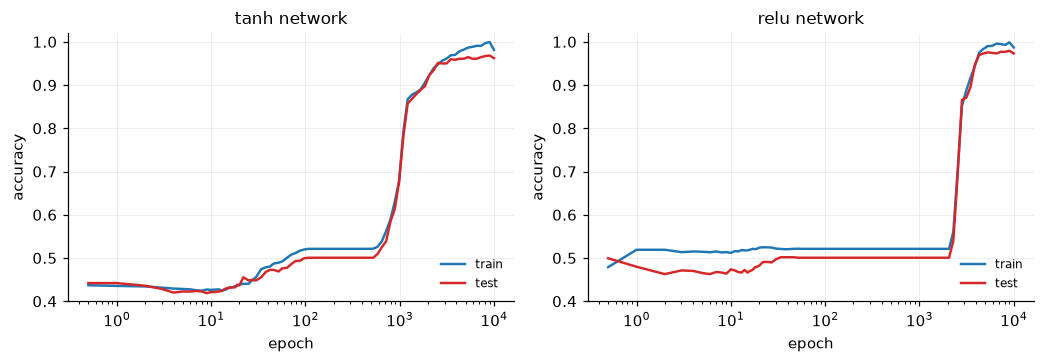

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(9.6, 3.4))
for ax, (name, lg) in zip(axes, [("tanh", log_tanh), ("relu", log_relu)]):
    x = np.maximum(lg["epochs"], 0.5)
    ax.plot(x, lg["train_acc"], label="train", color="#1f77b4")
    ax.plot(x, lg["test_acc"], label="test", color="#d62728")
    ax.set_xscale("log"); ax.set_ylim(0.4, 1.02)
    ax.set_xlabel("epoch"); ax.set_ylabel("accuracy"); ax.set_title(f"{name} network")
    ax.legend(loc="lower right")
fig.tight_layout(); save(fig, "fig02_learning_curves"); plt.show()

## 3.2 The headline figure

How to read an information plane: each layer traces one curve of dots, coloured by epoch
(dark = early, yellow = late). The **first hidden layer sits far right** — it knows the most
about $X$; the **output layer sits far left**. Faint lines join the layers at a common
epoch. Movement **right and up is fitting**; movement **left is compression**.

In [10]:
# tanh: bounded in [-1, 1] -> 30 equal bins there (paper section 2)
# ReLU: unbounded -> 100 equal bins spanning the extremes ever observed (appendix C)
relu_lo = min(float(a.min()) for acts in log_relu["activations"] for a in acts)
relu_hi = max(float(a.max()) for acts in log_relu["activations"] for a in acts)
print(f"tanh binning : 30 bins on [-1, 1]")
print(f"ReLU binning : 100 bins on [{relu_lo:.3f}, {relu_hi:.3f}]")

plane_tanh = cached("plane_tanh_uniform", lambda: information_plane(
    log_tanh["activations"], y_all, n_bins=30, bounds=(-1.0, 1.0)))
plane_relu = cached("plane_relu_uniform", lambda: information_plane(
    log_relu["activations"], y_all, n_bins=100, bounds=(relu_lo, relu_hi)))
ixt_tanh, ity_tanh = plane_tanh
ixt_relu, ity_relu = plane_relu

tanh binning : 30 bins on [-1, 1]
ReLU binning : 100 bins on [0.000, 56.306]


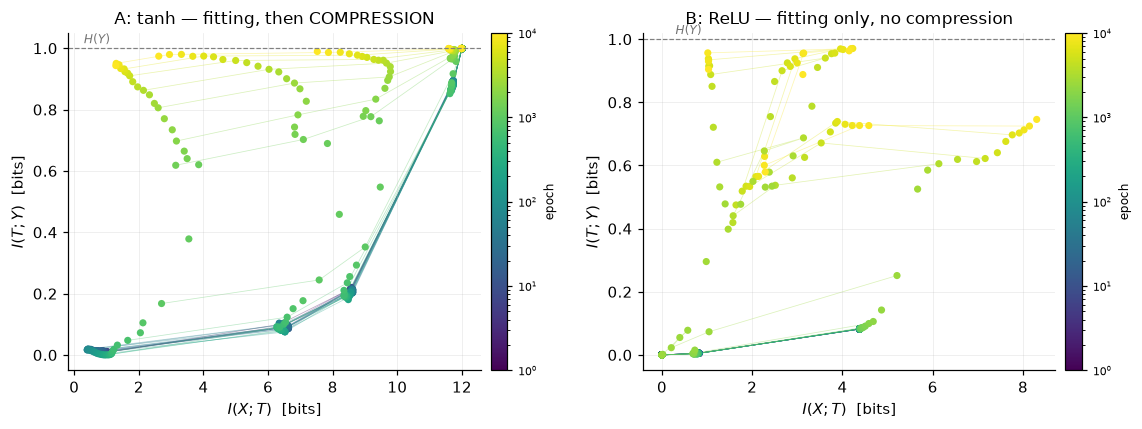

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(10.6, 4.0))
plot_plane(log_tanh["epochs"], ixt_tanh, ity_tanh, ax=axes[0],
           title="A: tanh — fitting, then COMPRESSION", layer_names=log_tanh["layer_names"])
plot_plane(log_relu["epochs"], ixt_relu, ity_relu, ax=axes[1],
           title="B: ReLU — fitting only, no compression", layer_names=log_relu["layer_names"])
for ax in axes:
    ax.axhline(H_Y, ls="--", lw=0.8, color="0.5")
    ax.text(0.3, H_Y + 0.015, r"$H(Y)$", fontsize=8, color="0.45")
fig.tight_layout(); save(fig, "fig03_information_plane"); plt.show()

In [12]:
def z(v):                      # avoid printing "-0.00"
    return 0.0 if abs(v) < 5e-3 else v

def compression_table(name, ixt, layer_names):
    print(f"{name} network")
    print(f"{'layer':12s} {'I(X;T) init':>12s} {'peak':>8s} {'final':>8s} {'compression':>13s}")
    print("-" * 58)
    for j, ln in enumerate(layer_names):
        x = ixt[:, j]
        print(f"{ln:12s} {z(x[0]):12.2f} {z(x.max()):8.2f} {z(x[-1]):8.2f} "
              f"{z(x.max() - x[-1]):13.2f}")
    print()
    return ixt.max(0) - ixt[-1]

drop_tanh = compression_table("tanh", ixt_tanh, log_tanh["layer_names"])
drop_relu = compression_table("ReLU", ixt_relu, log_relu["layer_names"])

print(f"TOTAL compression   tanh {drop_tanh.sum():6.2f} bits    ReLU {drop_relu.sum():6.2f} bits")
print(f"layers losing >0.5 bits: tanh {(drop_tanh > 0.5).sum()}/6, ReLU {(drop_relu > 0.5).sum()}/6")
print()
print(f"and the ReLU network's test accuracy is {log_relu['test_acc'][-1]:.3f} "
      f"vs tanh's {log_tanh['test_acc'][-1]:.3f}.")

tanh network
layer         I(X;T) init     peak    final   compression
----------------------------------------------------------
L1 (10)             12.00    12.00    12.00          0.00
L2 (7)              12.00    12.00    11.98          0.02
L3 (5)              11.71    11.82    11.59          0.23
L4 (4)               8.58     9.79     7.52          2.27
L5 (3)               6.36     8.20     2.62          5.59
L6 (2) out           1.04     3.85     1.29          2.56

ReLU network
layer         I(X;T) init     peak    final   compression
----------------------------------------------------------
L1 (10)              4.38     8.30     8.30          0.00
L2 (7)               0.82     4.58     4.58          0.00
L3 (5)               0.00     2.29     2.29          0.00
L4 (4)               0.00     3.14     3.12          0.02
L5 (3)               0.00     4.23     4.15          0.08
L6 (2) out           0.00     1.40     1.03          0.37

TOTAL compression   tanh  10.66 bits    Re

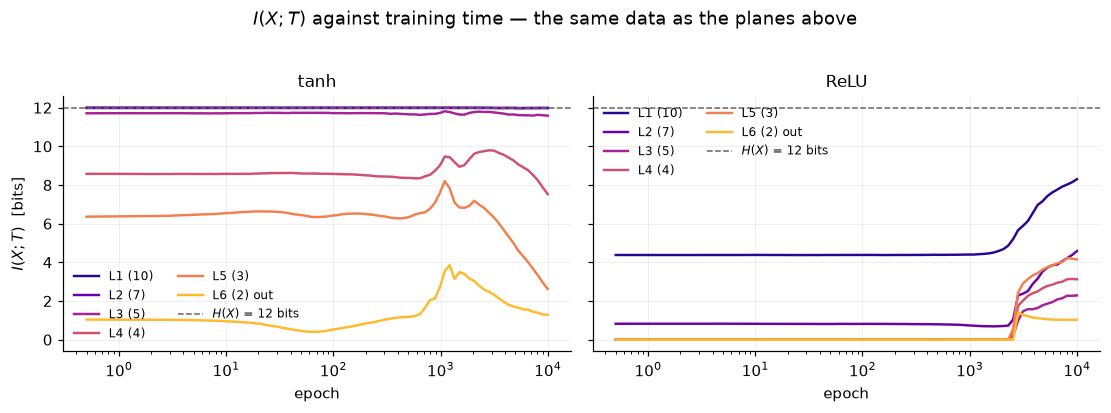

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(10.2, 3.6), sharey=True)
plot_layers(log_tanh["epochs"], ixt_tanh, ax=axes[0], layer_names=log_tanh["layer_names"],
            ylabel=r"$I(X;T)$  [bits]", title="tanh", hline=12.0, hline_label=r"$H(X)$ = 12 bits")
plot_layers(log_relu["epochs"], ixt_relu, ax=axes[1], layer_names=log_relu["layer_names"],
            title="ReLU", hline=12.0, hline_label=r"$H(X)$ = 12 bits")
fig.suptitle(r"$I(X;T)$ against training time — the same data as the planes above", y=1.03)
fig.tight_layout(); save(fig, "fig04_IXT_vs_epoch"); plt.show()

### What just happened

The tanh network **reproduces** Shwartz-Ziv & Tishby's two-phase picture exactly. The
original result is real and not a coding error.

The ReLU network — same data, same architecture, same optimiser, same measurement
procedure, same accuracy — shows essentially **no compression**, *except in its final
layer*. And the final layer is precisely the one layer that is still **sigmoidal**, i.e.
still double-saturating. The mechanism predicting its own exception is about as clean a
piece of evidence as one gets.

> **Claim 1 fails.** A compression phase is not a general property of deep learning. It is a
> property of *double-saturating nonlinearities measured by binning* — exactly what the
> one-neuron model of §2 predicted.

## 3.3 The mechanism, seen directly

If saturation is the cause, it should be visible in the activations themselves. Histogram
each layer's activity over training.

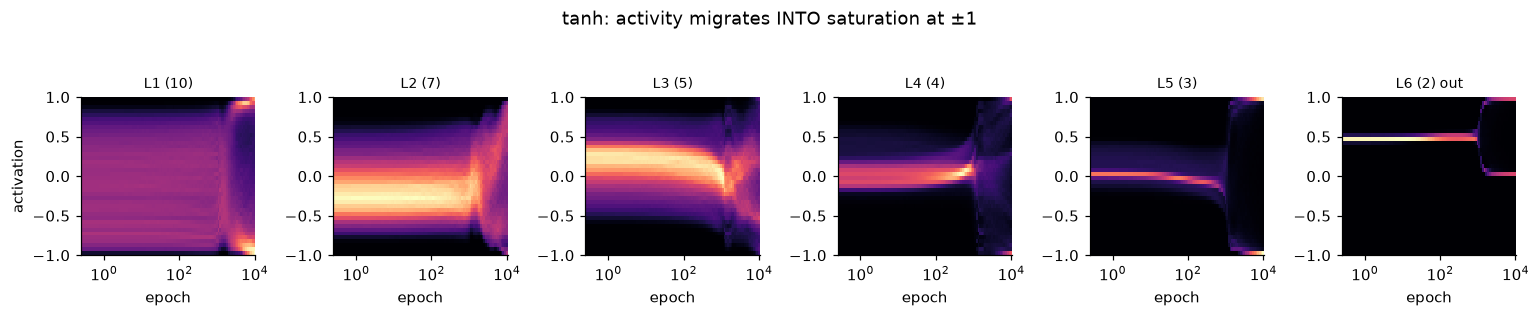

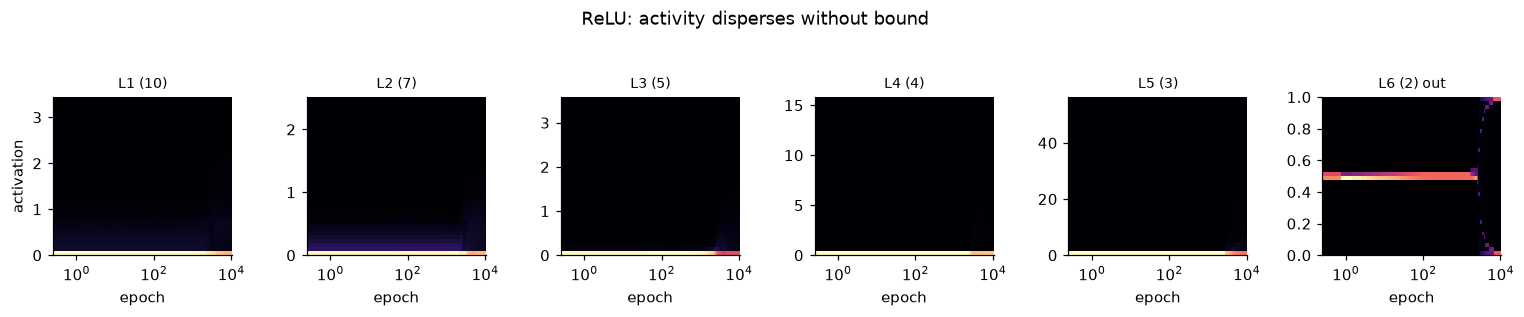

In [14]:
def activation_histograms(lg, bounds, title, name):
    acts, epochs = lg["activations"], lg["epochs"]
    n = len(acts[0])
    fig, axes = plt.subplots(1, n, figsize=(2.35 * n, 2.7))
    for j, ax in enumerate(axes):
        if bounds is None:
            lo = min(float(a[j].min()) for a in acts)
            hi = max(float(a[j].max()) for a in acts)
        else:
            lo, hi = bounds
        edges = np.linspace(lo, hi, 41)
        H = np.stack([np.histogram(a[j].ravel(), bins=edges)[0] for a in acts]).T.astype(float)
        H /= np.maximum(H.sum(0, keepdims=True), 1)
        ax.pcolormesh(np.maximum(epochs, 0.5), 0.5 * (edges[:-1] + edges[1:]), H,
                      cmap="magma", shading="nearest")
        ax.set_xscale("log"); ax.grid(False)
        ax.set_xlabel("epoch"); ax.set_title(lg["layer_names"][j], fontsize=9)
        if j == 0:
            ax.set_ylabel("activation")
    fig.suptitle(title, y=1.05); fig.tight_layout(); save(fig, name); plt.show()

activation_histograms(log_tanh, (-1.0, 1.0),
                      "tanh: activity migrates INTO saturation at $\\pm 1$", "fig05_acts_tanh")
activation_histograms(log_relu, None,
                      "ReLU: activity disperses without bound", "fig05_acts_relu")

In [15]:
print("fraction of tanh activations that are saturated (|h| > 0.98)")
print(f"{'layer':12s} {'epoch 0':>10s} {'final':>10s}")
print("-" * 34)
for j, ln in enumerate(log_tanh["layer_names"][:-1]):
    f0 = float(np.mean(np.abs(log_tanh["activations"][0][j]) > 0.98))
    f1 = float(np.mean(np.abs(log_tanh["activations"][-1][j]) > 0.98))
    print(f"{ln:12s} {f0:10.3f} {f1:10.3f}")

print()
print("fraction of ReLU activations at exactly zero, and the largest activation")
print(f"{'layer':12s} {'epoch 0':>10s} {'final':>10s} {'max |h| final':>15s}")
print("-" * 50)
for j, ln in enumerate(log_relu["layer_names"][:-1]):
    z0 = float(np.mean(log_relu["activations"][0][j] == 0))
    z1 = float(np.mean(log_relu["activations"][-1][j] == 0))
    mx = float(log_relu["activations"][-1][j].max())
    print(f"{ln:12s} {z0:10.3f} {z1:10.3f} {mx:15.2f}")
print()
print("tanh: mass piles up against the two asymptotes -> distinct patterns merge -> H(T) falls.")
print("ReLU: a roughly constant fraction sits at 0 while the rest spreads out -> H(T) rises.")

fraction of tanh activations that are saturated (|h| > 0.98)
layer           epoch 0      final
----------------------------------
L1 (10)           0.001      0.039
L2 (7)            0.000      0.006
L3 (5)            0.000      0.015
L4 (4)            0.000      0.170
L5 (3)            0.000      0.754

fraction of ReLU activations at exactly zero, and the largest activation
layer           epoch 0      final   max |h| final
--------------------------------------------------
L1 (10)           0.583      0.505            3.44
L2 (7)            0.457      0.458            2.51
L3 (5)            0.852      0.547            3.58
L4 (4)            0.814      0.672           15.81
L5 (3)            0.631      0.669           56.31

tanh: mass piles up against the two asymptotes -> distinct patterns merge -> H(T) falls.
ReLU: a roughly constant fraction sits at 0 while the rest spreads out -> H(T) rises.


## 3.4 Compression *without* generalisation

**Paper figures 4C–D.** A quick but important control: train the same tanh network on only
**30%** of the patterns, so that it overfits noticeably. If compression caused
generalisation, a network that fails to generalise should fail to compress.

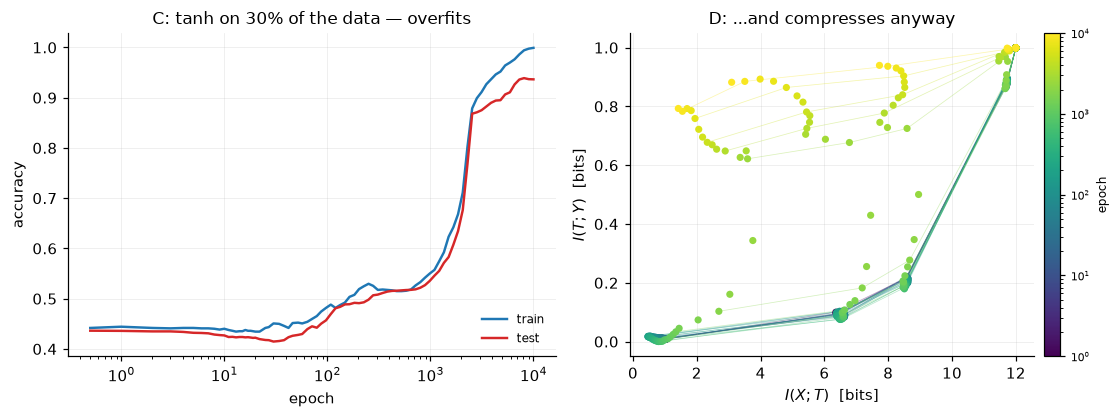

train acc 0.999   test acc 0.937   generalisation gap 0.063
total compression: 7.99 bits

So we now have a network that compresses heavily and generalises POORLY, next to a
ReLU network that barely compresses and generalises WELL. Compression and
generalisation are already coming apart; section 5 completes the dissociation.


In [16]:
log_of = cached("mlp_tanh_sgd_30pct",
                lambda: train_mlp(activation="tanh", train_fraction=0.3))
plane_of = cached("plane_tanh_30pct", lambda: information_plane(
    log_of["activations"], y_all, n_bins=30, bounds=(-1.0, 1.0)))
ixt_of, ity_of = plane_of

fig, axes = plt.subplots(1, 2, figsize=(10.4, 3.9))
x = np.maximum(log_of["epochs"], 0.5)
axes[0].plot(x, log_of["train_acc"], label="train", color="#1f77b4")
axes[0].plot(x, log_of["test_acc"], label="test", color="#d62728")
axes[0].set_xscale("log"); axes[0].set_xlabel("epoch"); axes[0].set_ylabel("accuracy")
axes[0].set_title("C: tanh on 30% of the data — overfits"); axes[0].legend(loc="lower right")
plot_plane(log_of["epochs"], ixt_of, ity_of, ax=axes[1],
           title="D: ...and compresses anyway", layer_names=log_of["layer_names"])
fig.tight_layout(); save(fig, "fig06_overfit_tanh"); plt.show()

gap = log_of["train_acc"][-1] - log_of["test_acc"][-1]
print(f"train acc {log_of['train_acc'][-1]:.3f}   test acc {log_of['test_acc'][-1]:.3f}   "
      f"generalisation gap {gap:.3f}")
print(f"total compression: {(ixt_of.max(0) - ixt_of[-1]).sum():.2f} bits")
print()
print("So we now have a network that compresses heavily and generalises POORLY, next to a")
print("ReLU network that barely compresses and generalises WELL. Compression and")
print("generalisation are already coming apart; section 5 completes the dissociation.")

---

# 4. The measurement decides the answer

**Paper appendix C, figures C2–C3.**

Sections 2 and 3 leave one escape route open: perhaps 30 uniform bins are simply the
*right* way to measure, and the tanh result is what a correct measurement shows. So take the
tanh network we already trained — **same weights, same run, same data, nothing retrained** —
and change only the definition of $T$.

## 4.1 Move the bin edges

Instead of bins uniform in *activation*, use bins uniform in *net input*: edges at
$b_i \in \tanh(\mathrm{linspace}(-50,50,N))$. This is just as defensible a convention: it
places bins where a saturating unit's net input actually varies.

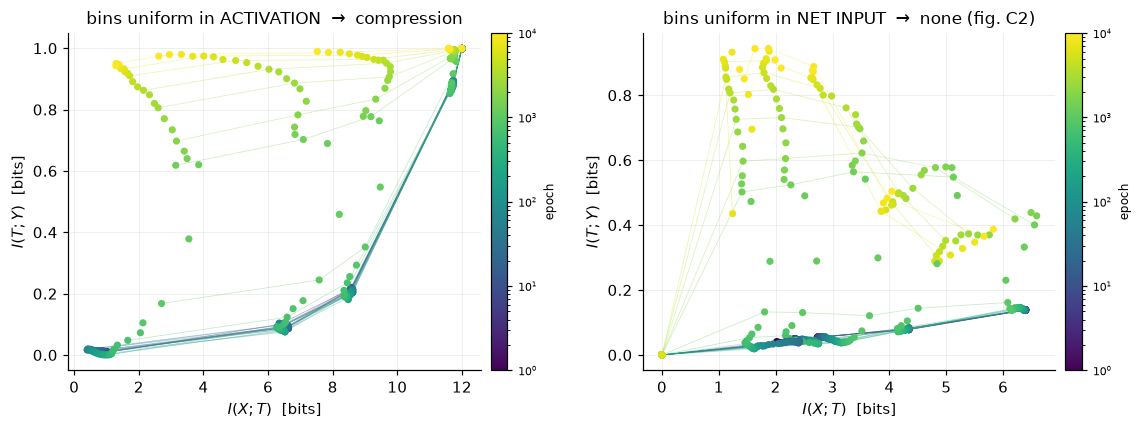

SAME network, SAME weights, SAME training run. Only the bin edges differ.
layer          uniform in activation    uniform in net input
------------------------------------------------------------
L1 (10)                    0.00 bits               0.76 bits
L2 (7)                     0.02 bits               1.15 bits
L3 (5)                     0.23 bits               1.15 bits
L4 (4)                     2.27 bits               0.77 bits
L5 (3)                     5.59 bits               0.32 bits
L6 (2) out                 2.56 bits               0.22 bits


In [17]:
plane_ni = cached("plane_tanh_netinput", lambda: information_plane(
    log_tanh["activations"], y_all, scheme="net_input", n_bins=30))
ixt_ni, ity_ni = plane_ni

fig, axes = plt.subplots(1, 2, figsize=(10.6, 4.0))
plot_plane(log_tanh["epochs"], ixt_tanh, ity_tanh, ax=axes[0],
           title="bins uniform in ACTIVATION  →  compression", layer_names=log_tanh["layer_names"])
plot_plane(log_tanh["epochs"], ixt_ni, ity_ni, ax=axes[1],
           title="bins uniform in NET INPUT  →  none (fig. C2)", layer_names=log_tanh["layer_names"])
fig.tight_layout(); save(fig, "fig07_binning_flips_conclusion"); plt.show()

print("SAME network, SAME weights, SAME training run. Only the bin edges differ.")
print(f"{'layer':12s} {'uniform in activation':>23s} {'uniform in net input':>23s}")
print("-" * 60)
for j, ln in enumerate(log_tanh["layer_names"]):
    a = ixt_tanh[:, j].max() - ixt_tanh[-1, j]
    b = ixt_ni[:, j].max() - ixt_ni[-1, j]
    print(f"{ln:12s} {a:>18.2f} bits {b:>18.2f} bits")

## 4.2 Change the resolution

A real network on real hardware *is* finite-precision — but at roughly $2^{32}$ levels per
unit, not 30. Bin at that resolution (two activities share a symbol only if their float32
bit patterns are identical) and every one of the 4096 patterns gets its own code, so
$I(X;T)$ is pinned at $\log_2 4096 = 12$ bits with no dynamics whatever.

Between "30 bins" and "machine precision" lies a continuum, and the answer slides along it.

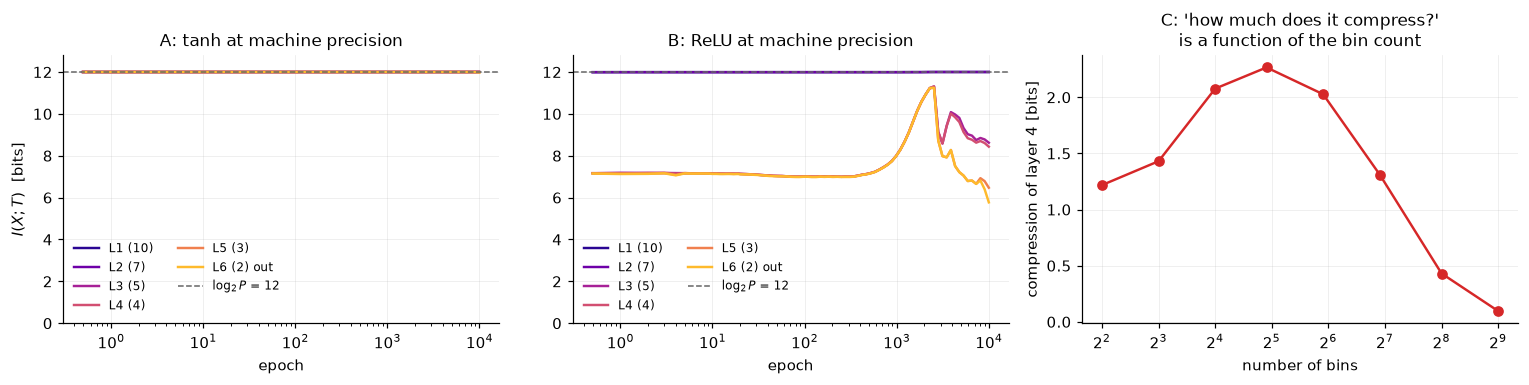

At machine precision, I(X;T) = log2(4096) = 12 bits, essentially with no dynamics:
  tanh final : [12.   12.   12.   12.   12.   11.98]
  ReLU final : [12.   12.    8.62  8.43  6.47  5.77]

The ReLU network falls below 12 in its deeper layers for a reason worth knowing:
a ReLU unit that is off outputs EXACTLY zero, and whole units switch off together,
so many activation vectors are bit-identical and genuinely share a symbol. That is a
real atom in the distribution, not an artefact -- and it is why differential-entropy
estimators (KDE, k-NN) are ill-defined on ReLU layers.

  bins  I(X;T) peak    final  compression   (layer 4)
----------------------------------------------
     4         4.04     2.82         1.22
     8         5.90     4.47         1.43
    16         7.96     5.88         2.08
    30         9.79     7.52         2.27
    60        11.28     9.26         2.03
   120        11.90    10.59         1.31
   256        12.00    11.57         0.43
   512        12.00    11

In [18]:
plane_mp_tanh = cached("plane_tanh_exact", lambda: information_plane(
    log_tanh["activations"], y_all, scheme="exact"))
plane_mp_relu = cached("plane_relu_exact", lambda: information_plane(
    log_relu["activations"], y_all, scheme="exact"))

def bincount_sweep(lg, bounds, counts=(4, 8, 16, 30, 60, 120, 256, 512)):
    out = {}
    for nb in counts:
        ixt, _ = information_plane(lg["activations"], y_all, n_bins=nb, bounds=bounds)
        out[nb] = ixt
    return out

sweep = cached("sweep_tanh_bins", lambda: bincount_sweep(log_tanh, (-1.0, 1.0)))

fig, axes = plt.subplots(1, 3, figsize=(14.0, 3.6))
plot_layers(log_tanh["epochs"], plane_mp_tanh[0], ax=axes[0], layer_names=log_tanh["layer_names"],
            ylabel=r"$I(X;T)$  [bits]", title="A: tanh at machine precision",
            hline=12.0, hline_label=r"$\log_2 P$ = 12")
plot_layers(log_relu["epochs"], plane_mp_relu[0], ax=axes[1], layer_names=log_relu["layer_names"],
            title="B: ReLU at machine precision", hline=12.0, hline_label=r"$\log_2 P$ = 12")
# Fix a common y-range on both: without it matplotlib offsets the tanh axis to
# "+1.199e1" and the flat line at 12 bits reads as a line at 0.01.
for ax_ in (axes[0], axes[1]):
    ax_.set_ylim(0, 12.8)

ax = axes[2]
cts = sorted(sweep)
comp = [ (sweep[n][:, 3].max() - sweep[n][-1, 3]) for n in cts ]   # layer 4, a middle layer
ax.plot(cts, comp, "o-", color="#d62728")
ax.set_xscale("log", base=2); ax.set_xlabel("number of bins")
ax.set_ylabel("compression of layer 4 [bits]")
ax.set_title("C: 'how much does it compress?'\nis a function of the bin count")
fig.tight_layout(); save(fig, "fig08_resolution"); plt.show()

print("At machine precision, I(X;T) = log2(4096) = 12 bits, essentially with no dynamics:")
print(f"  tanh final : {np.round(plane_mp_tanh[0][-1], 2)}")
print(f"  ReLU final : {np.round(plane_mp_relu[0][-1], 2)}")
print()
print("The ReLU network falls below 12 in its deeper layers for a reason worth knowing:")
print("a ReLU unit that is off outputs EXACTLY zero, and whole units switch off together,")
print("so many activation vectors are bit-identical and genuinely share a symbol. That is a")
print("real atom in the distribution, not an artefact -- and it is why differential-entropy")
print("estimators (KDE, k-NN) are ill-defined on ReLU layers.")
print()
print(f"{'bins':>6s} {'I(X;T) peak':>12s} {'final':>8s} {'compression':>12s}   (layer 4)")
print("-" * 46)
for n in cts:
    x = sweep[n][:, 3]
    print(f"{n:>6d} {x.max():>12.2f} {x[-1]:>8.2f} {x.max() - x[-1]:>12.2f}")

## 4.3 A different estimator — and a case where it fails silently

*This subsection goes beyond the paper.*

Binning is crude, so the natural move is a better estimator. Appendix B.3 uses the
**Kraskov / Kozachenko–Leonenko $k$-nearest-neighbour** estimator, and it comes with an
attractive argument. If $T = h + Z$ with $Z$ independent of $X$, then

$$I(T;X) = H(T) - H(T \mid X) = H(T) - H(Z) = H(T) - c$$

for a **constant** $c$. So you never have to commit to a noise level at all: whether a layer
*compresses* — the only question at issue — can be read off $H(T)$ alone. Falling entropy
means compression. The estimator is

$$\hat{H} = \frac{d}{P}\sum_{i=1}^{P}\log(r_i + \varepsilon) + \frac{d}{2}\log\pi
  - \log\Gamma\!\big(\tfrac{d}{2}+1\big) + \psi(P) - \psi(k) \tag{B.10}$$

with $r_i$ the distance from point $i$ to its $k$-th nearest neighbour. The $\varepsilon$
is described in the paper as preventing infinite terms.

The estimator has one load-bearing assumption: the distribution must be **absolutely
continuous** — no atoms. Keep that in mind and run it on both networks.

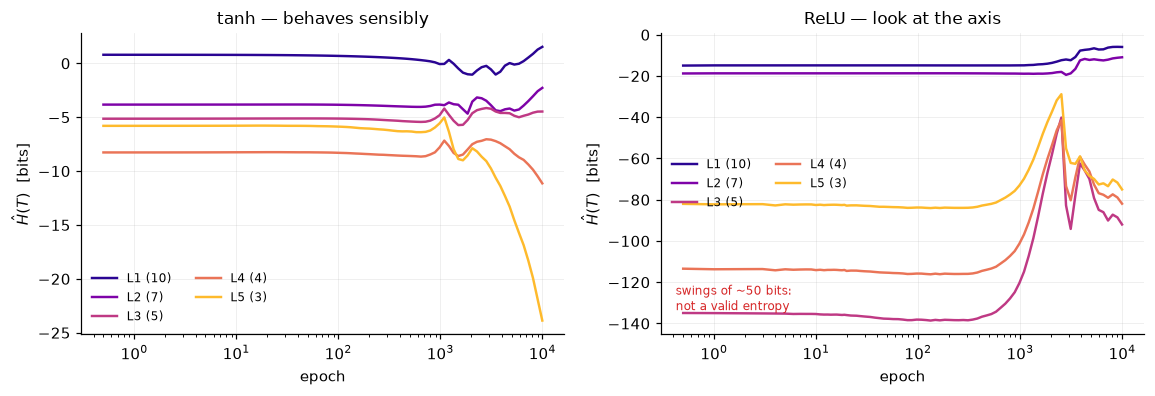

        layer       H start   H final    swing   binning said
--------------------------------------------------------------
tanh    L1 (10)         0.8       1.5      2.6        0.00 b
tanh    L2 (7)         -3.8      -2.3      2.4        0.03 b
tanh    L3 (5)         -5.1      -4.5      1.6        0.23 b
tanh    L4 (4)         -8.3     -11.1      4.1        2.27 b
tanh    L5 (3)         -5.8     -23.9     18.9        5.59 b

ReLU    L1 (10)       -14.9      -5.9      9.1        3.93 b
ReLU    L2 (7)        -18.8     -10.9      8.5        3.90 b
ReLU    L3 (5)       -134.9     -92.0     98.4        2.29 b
ReLU    L4 (4)       -113.4     -81.9     74.6        3.14 b
ReLU    L5 (3)        -82.0     -75.0     55.2        4.23 b

tanh: entropy falls in layers 4 and 5 -- the same layers binning found compressing.
      The two estimators AGREE in sign. (Magnitudes are not comparable: one is a
      differential entropy, the other a discrete one.)

ReLU: swings of 55 to 98 bits, in layers w

In [19]:
from scipy.spatial import cKDTree
from scipy.special import digamma, gammaln

def entropy_kraskov(h, k=2, eps=1e-16):
    """Kozachenko-Leonenko differential entropy in bits -- paper eq. (B.10)."""
    X = np.asarray(h, dtype=np.float64)
    P, d = X.shape
    r = cKDTree(X).query(X, k=k + 1)[0][:, k]     # k-th neighbour (the 0th is itself)
    nats = ((d / P) * np.sum(np.log(r + eps))
            + (d / 2) * np.log(np.pi) - gammaln(d / 2 + 1)
            + digamma(P) - digamma(k))
    return float(nats / np.log(2))

def duplicate_fraction(h):
    """Fraction of activation vectors that are exact duplicates of another."""
    X = np.asarray(h)
    return 1.0 - len(np.unique(X, axis=0)) / len(X)

def kraskov_curve(lg):
    # hidden layers only, matching the paper's figure B5
    return np.array([[entropy_kraskov(a) for a in acts[:-1]] for acts in lg["activations"]])

H_tanh = cached("kraskov_tanh", lambda: kraskov_curve(log_tanh))
H_relu = cached("kraskov_relu", lambda: kraskov_curve(log_relu))
hidden = log_tanh["layer_names"][:-1]

fig, axes = plt.subplots(1, 2, figsize=(10.6, 3.7))
plot_layers(log_tanh["epochs"], H_tanh, ax=axes[0], layer_names=hidden,
            ylabel=r"$\hat{H}(T)$  [bits]", title="tanh — behaves sensibly")
plot_layers(log_relu["epochs"], H_relu, ax=axes[1], layer_names=hidden,
            ylabel=r"$\hat{H}(T)$  [bits]", title="ReLU — look at the axis")
axes[1].text(0.03, 0.08, "swings of ~50 bits:\nnot a valid entropy",
             transform=axes[1].transAxes, fontsize=8, color="#d62728")
fig.tight_layout(); save(fig, "fig08b_kraskov"); plt.show()

print(f"{'':7s} {'layer':9s} {'H start':>9s} {'H final':>9s} {'swing':>8s} "
      f"{'binning said':>14s}")
print("-" * 62)
for name, H, ixt in [("tanh", H_tanh, ixt_tanh), ("ReLU", H_relu, ixt_relu)]:
    for j, ln in enumerate(hidden):
        print(f"{name:7s} {ln:9s} {H[0, j]:>9.1f} {H[-1, j]:>9.1f} "
              f"{H[:, j].max() - H[:, j].min():>8.1f} "
              f"{ixt[:, j].max() - ixt[:, j].min():>11.2f} b")
    print()
print("tanh: entropy falls in layers 4 and 5 -- the same layers binning found compressing.")
print("      The two estimators AGREE in sign. (Magnitudes are not comparable: one is a")
print("      differential entropy, the other a discrete one.)")
print()
print("ReLU: swings of 55 to 98 bits, in layers whose binned I(X;T) moves by under 4 bits")
print("      in total. Read literally this is a huge COMPRESSION PHASE in the one network")
print("      we have every other reason to believe does not compress. Something is wrong.")

### Why it fails, exactly

The Kozachenko–Leonenko estimator assumes an **absolutely continuous** distribution. A ReLU
layer violates that badly: a unit that is off outputs *exactly* $0$, and whole units switch
off together, so a substantial fraction of activation vectors are **bit-identical**. The
distribution is mixed discrete–continuous, and differential entropy is not defined for it.

Operationally, $r_i = 0$ for those points and the $\varepsilon$ guard takes over: each
duplicated point contributes $(d/P)\log\varepsilon$, which for $\varepsilon = 10^{-16}$ is
$\approx -36.8$ nats per dimension. The estimate then tracks **how many points coincide**,
not how spread out the representation is.

(This is *not* an objection to large negative numbers as such. A differential entropy is
allowed to be very negative — a distribution that concentrates has one, which is exactly why
the saturating tanh layers report $-24$ bits legitimately. The question is whether the
number is a function of the data or of $\varepsilon$.)

That is a testable claim, so let us test it: predict each layer's entropy from the duplicate
count *alone*, and compare with what the estimator returned.

In [20]:
print(f"{'':7s} {'layer':9s} {'d':>3s} {'duplicates':>11s} {'measured H':>12s} "
      f"{'eps-guard term alone':>21s}")
print("-" * 68)
for name, lg, H in [("tanh", log_tanh, H_tanh), ("ReLU", log_relu, H_relu)]:
    for j, ln in enumerate(hidden):
        a = lg["activations"][-1][j]
        f, d = duplicate_fraction(a), a.shape[1]
        guard = d * f * np.log(1e-16) / np.log(2)      # (d/P) * sum over duplicated points
        print(f"{name:7s} {ln:9s} {d:>3d} {f:>11.3f} {H[-1, j]:>12.1f} {guard:>21.1f}")
    print()
print("tanh has NO duplicates at any layer, so eps never engages: its -24 bits are a real")
print("(if extreme) differential entropy, produced by a layer that genuinely concentrates.")
print()
print("For ReLU layers 3-5 the eps term ALONE reproduces the measured value to within a few")
print("bits. The estimator is reporting eps, not the data -- and since the duplicate count")
print("changes over training, so does the 'entropy'. That is the whole 50-bit phase.")
print()
print("The paper's appendix B.3 introduces eps to 'prevent infinite terms' but does not note")
print("that the estimate stops being an entropy once it dominates. So: read the tanh panel,")
print("and treat the ReLU panel as a diagnostic of the estimator, not of the network.")

        layer       d  duplicates   measured H  eps-guard term alone
--------------------------------------------------------------------
tanh    L1 (10)    10       0.000          1.5                  -0.0
tanh    L2 (7)      7       0.000         -2.3                  -0.0
tanh    L3 (5)      5       0.000         -4.5                  -0.0
tanh    L4 (4)      4       0.000        -11.1                  -0.0
tanh    L5 (3)      3       0.000        -23.9                  -0.0

ReLU    L1 (10)    10       0.000         -5.9                  -0.0
ReLU    L2 (7)      7       0.000        -10.9                  -0.0
ReLU    L3 (5)      5       0.325        -92.0                 -86.4
ReLU    L4 (4)      4       0.353        -81.9                 -75.0
ReLU    L5 (3)      3       0.502        -75.0                 -80.0

tanh has NO duplicates at any layer, so eps never engages: its -24 bits are a real
(if extreme) differential entropy, produced by a layer that genuinely concentrates.

Fo

### Reading §4

Hold the network completely fixed and vary only the analyst's choice:

* **bin edges** (uniform in activation vs uniform in net input) — the compression phase
  appears or disappears;
* **bin count** — the measured compression of one layer swings by a factor of 20 (0.10 to
  2.27 bits) and is not even monotone in the resolution;
* **machine precision** — the curve is a flat line at $\log_2 P$;
* **switch estimator entirely** — and a $k$-NN estimator invents a 50-bit compression phase
  in the network that does not compress, because its validity assumption is quietly false.

A quantity whose *sign* depends on an arbitrary analysis convention is not measuring a
property of the network. This is the paper's deepest point, and it does not depend on any
empirical result at all.

> Note also what this does **not** say: it does not say the tanh network is unchanged. It
> genuinely saturates (§3.3). What is in dispute is whether "the representation lost 10 bits
> of information about the input" is a fair description of that.

---

# 5. Removing the estimator entirely: deep linear networks

**Paper section 3, figures 3, 4A–B.**

A natural objection to §4: maybe binning is just a crude estimator, and a *better* one would
show real compression. The way to settle that is to remove estimation from the problem.

In a **deep linear network** $\hat{Y} = W_D \cdots W_1 X$ with Gaussian inputs, every hidden
layer is jointly Gaussian with the input and the output. The network is still worth studying
— its optimisation problem is non-convex, its learning dynamics are genuinely nonlinear in
time (Saxe, McClelland & Ganguli 2014), and it exhibits real overtraining (Advani & Saxe
2017) — but now **the mutual information is available in closed form.**

## The model

$$X \sim \mathcal{N}\!\Big(0, \tfrac{1}{N_i} I\Big), \qquad
  Y = W_o X + \epsilon_o, \qquad \epsilon_o \sim \mathcal{N}(0, \sigma_o^2),$$

with the student computing $T = \bar{W} X$ where $\bar{W} = W_l \cdots W_1$. Since $T$ is
deterministic in $X$, $I(T;X) = \infty$ as always — so, **for the analysis only**, we set

$$T = \bar{W}X + \epsilon_{MI}, \qquad \epsilon_{MI} \sim \mathcal{N}(0, \sigma_{MI}^2 I),
  \qquad \sigma_{MI}^2 = 1.$$

This noise is *not* present during training or testing; it is the §1.2 "noise" assumption,
and its role is to set the resolution at which the representation is read out. Then, with
$\Sigma_T = \bar{W}\Sigma_X\bar{W}^\top + \sigma_{MI}^2 I$,

$$I(T;X) = \tfrac12\log|\Sigma_T| - \tfrac12\log|\sigma_{MI}^2 I| \tag{6}$$

$$I(T;Y) = H(T) + H(Y) - H(T,Y) \tag{G.1–G.4}$$

$$E_g = \mathrm{tr}\big[(W_o - W_{tot})\Sigma_X(W_o - W_{tot})^\top\big] + \sigma_o^2 N_o \tag{5}$$

— all exact, all with no estimator involved. $E_g$ is the *true* expected generalisation
error, not a test-set estimate.

> **A note on the paper's own equations.** The text states $X \sim \mathcal{N}(0, I/N_i)$
> but writes eqs (5), (6) and (G.1)–(G.3) with $\Sigma_X$ suppressed, as if $\Sigma_X = I$;
> and eq. (6) drops the factor $\tfrac12$ that appears correctly in (G.2). We carry
> $\Sigma_X$ explicitly and keep the $\tfrac12$. This changes the axis scale by a constant
> and no conclusion — and it puts $I(X;T)$ in the same $\approx 0.5$–$2.5$ bit range as the
> paper's own figure 3D.

In [21]:
def make_teacher(n_inputs=100, n_train=100, n_test=10_000, snr=1.0, sigma_w=1.0,
                 n_relevant=None, seed=0):
    """Linear student/teacher problem.  n_relevant=k zeroes the teacher's weights
    on all inputs past the k-th, creating an explicitly task-irrelevant subspace."""
    rng = np.random.default_rng(seed)
    sigma_o = float(np.sqrt(sigma_w**2 / snr))
    W_o = rng.normal(0.0, sigma_w, size=(1, n_inputs))
    if n_relevant is not None:
        W_o[:, n_relevant:] = 0.0

    def sample(P):
        X = rng.normal(0.0, 1.0 / np.sqrt(n_inputs), size=(P, n_inputs))
        return X, X @ W_o.T + rng.normal(0.0, sigma_o, size=(P, 1))

    Xtr, Ytr = sample(n_train)
    Xte, Yte = sample(n_test)
    return dict(X_train=Xtr, Y_train=Ytr, X_test=Xte, Y_test=Yte,
                W_o=W_o, sigma_o=sigma_o, n_inputs=n_inputs)


class LinearNet:
    """Deep linear network Yhat = W_L ... W_1 X, in plain NumPy (~100x faster
    than torch at this size, and the gradients are three lines of algebra)."""

    def __init__(self, sizes, init_std="fan_in", seed=0):
        rng = np.random.default_rng(seed)
        self.sizes = list(sizes)
        self.weights = [
            rng.normal(0.0, 1.0 / np.sqrt(a) if init_std == "fan_in" else float(init_std),
                       size=(b, a))
            for a, b in zip(sizes[:-1], sizes[1:])
        ]
        self.layer_names = [f"L{i+1} ({n})" for i, n in enumerate(sizes[1:])]

    def forward(self, X):
        acts, h = [], X
        for W in self.weights:
            h = h @ W.T
            acts.append(h)
        return h, acts

    def layer_maps(self):
        """Cumulative maps Wbar_l = W_l ... W_1 -- the Wbar of paper eq (6)."""
        maps, W = [], None
        for Wl in self.weights:
            W = Wl.copy() if W is None else Wl @ W
            maps.append(W.copy())
        return maps


def train_linear(net, prob, lr=0.02, n_epochs=500, batch_size=None,
                 n_checkpoints=80, seed=0):
    """Gradient descent on summed-squared error, logging the exact layer maps."""
    X, Y, Xte, Yte = prob["X_train"], prob["Y_train"], prob["X_test"], prob["Y_test"]
    P = len(X)
    bs = P if batch_size is None else batch_size
    rng = np.random.default_rng(seed)
    ckpts = {int(c) for c in log_spaced(n_epochs, n_checkpoints)}
    out = {"epochs": [], "layer_maps": [], "train_mse": [], "test_mse": [],
           "grad_snr": [], "weight_norms": [], "layer_names": net.layer_names}

    def mse(A, B):
        o, _ = net.forward(A)
        return float(((B - o) ** 2).sum(-1).mean())

    def grads(Xb, Yb):
        out_, acts = net.forward(Xb)
        delta = -2.0 * (Yb - out_)                     # dE/d(output)
        gs = [None] * len(net.weights)
        for l in range(len(net.weights) - 1, -1, -1):
            h_prev = Xb if l == 0 else acts[l - 1]
            gs[l] = delta.T @ h_prev / len(Xb)         # dE/dW_l = delta h^T
            if l > 0:
                delta = delta @ net.weights[l]         # backprop
        return gs

    def grad_snr():
        """||mean per-sample gradient|| / ||elementwise std||, paper eqs (I.1)-(I.2)."""
        out_, acts = net.forward(X)
        delta = -2.0 * (Y - out_)
        vals = []
        for l in range(len(net.weights) - 1, -1, -1):
            h_prev = X if l == 0 else acts[l - 1]
            m = delta.T @ h_prev / P                   # E[G]
            s2 = (delta**2).T @ (h_prev**2) / P        # E[G^2]
            sd = np.sqrt(np.maximum(s2 - m**2, 0.0))
            vals.append(np.linalg.norm(m) / max(np.linalg.norm(sd), 1e-300))
            if l > 0:
                delta = delta @ net.weights[l]
        return vals[::-1]

    def record(ep):
        out["epochs"].append(ep)
        out["layer_maps"].append(net.layer_maps())
        out["train_mse"].append(mse(X, Y))
        out["test_mse"].append(mse(Xte, Yte))
        out["grad_snr"].append(grad_snr())
        out["weight_norms"].append([float(np.linalg.norm(W)) for W in net.weights])

    record(0)
    for ep in range(1, n_epochs + 1):
        if bs >= P:
            for l, g in enumerate(grads(X, Y)):
                net.weights[l] -= lr * g
        else:
            perm = rng.permutation(P)
            for s in range(0, P, bs):
                idx = perm[s:s + bs]
                for l, g in enumerate(grads(X[idx], Y[idx])):
                    net.weights[l] -= lr * g
        if ep in ckpts:
            record(ep)

    for k in ("epochs", "train_mse", "test_mse", "grad_snr", "weight_norms"):
        out[k] = np.array(out[k])
    return out


# ---- exact mutual information for T = Wbar X + eps_MI ---------------------- #
def _logdet(A):
    return float(np.linalg.slogdet(np.asarray(A, dtype=np.float64))[1])

def _Sigma_X(ni):
    return np.eye(ni) / ni          # the paper's X ~ N(0, I/N_i)

def mi_XT(W, sigma_mi2=1.0):
    """I(T;X), paper eq (6)."""
    nh, ni = W.shape
    S_T = W @ _Sigma_X(ni) @ W.T + sigma_mi2 * np.eye(nh)
    return (_logdet(S_T) - nh * np.log(sigma_mi2)) / (2 * np.log(2))

def mi_TY(W, W_o, sigma_o, sigma_mi2=1.0):
    """I(T;Y) = H(T) + H(Y) - H(T,Y), paper eqs (G.1)-(G.4)."""
    nh, ni = W.shape
    no = W_o.shape[0]
    Sx = _Sigma_X(ni)
    S_T = W @ Sx @ W.T + sigma_mi2 * np.eye(nh)
    S_Y = W_o @ Sx @ W_o.T + sigma_o**2 * np.eye(no)
    S_TY = W @ Sx @ W_o.T
    joint = np.block([[S_T, S_TY], [S_TY.T, S_Y]])
    return (_logdet(S_T) + _logdet(S_Y) - _logdet(joint)) / (2 * np.log(2))

def mi_subspace(W, sl, sigma_mi2=1.0):
    """I(T; X_S) for a block S of input coordinates: conditioning on X_S leaves
    the complement acting as extra noise."""
    nh, ni = W.shape
    Sx = _Sigma_X(ni)
    keep = np.zeros(ni, bool); keep[sl] = True
    S_T = W @ Sx @ W.T + sigma_mi2 * np.eye(nh)
    Wc = W[:, ~keep]
    S_cond = Wc @ Sx[np.ix_(~keep, ~keep)] @ Wc.T + sigma_mi2 * np.eye(nh)
    return (_logdet(S_T) - _logdet(S_cond)) / (2 * np.log(2))

def gen_error(W_tot, W_o, sigma_o):
    """Exact expected generalisation error, paper eq (5)."""
    ni = W_o.shape[1]
    D = W_o - W_tot
    return float(np.trace(D @ _Sigma_X(ni) @ D.T) + sigma_o**2 * W_o.shape[0])

## 5.1 A network that generalises — and never compresses

Figure 3: $N_i = 100$, one hidden layer of 100 units, $P = 100$ training samples,
$\mathrm{SNR} = 1$, full-batch gradient descent.

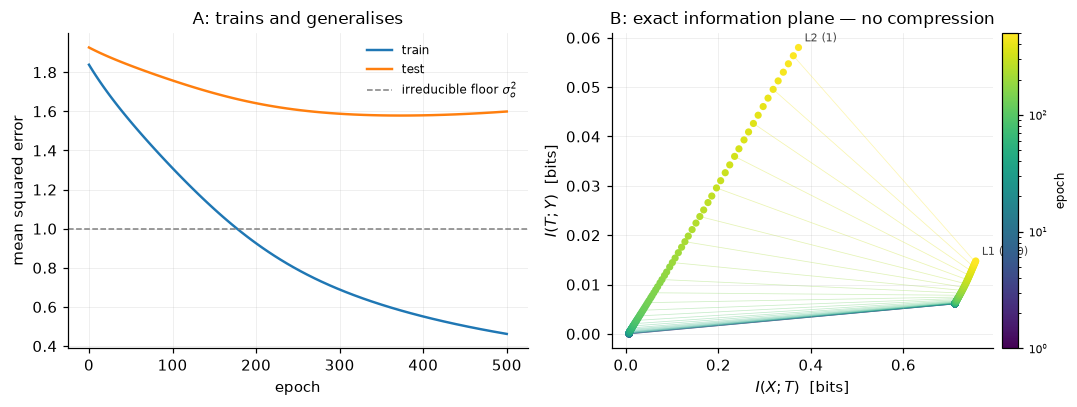

test MSE 1.93 -> 1.599   (irreducible floor 1.00)
exact E_g 1.95 -> 1.609

layer       I(X;T) start    final   compression (peak-final)
------------------------------------------------------------
L1 (100)           0.712    0.756                   0.000000
L2 (1)             0.007    0.373                   0.000000

Both layers move monotonically RIGHT. Good generalisation, zero compression.


In [22]:
def run_linear(sizes, prob_kw, train_kw, seed=0):
    prob = make_teacher(seed=seed, **prob_kw)
    net = LinearNet(sizes, init_std=train_kw.pop("init_std", "fan_in"), seed=seed)
    lg = train_linear(net, prob, seed=seed, **train_kw)
    lg["I_XT"] = np.array([[mi_XT(W) for W in maps] for maps in lg["layer_maps"]])
    lg["I_TY"] = np.array([[mi_TY(W, prob["W_o"], prob["sigma_o"]) for W in maps]
                           for maps in lg["layer_maps"]])
    lg["E_g"] = np.array([gen_error(maps[-1], prob["W_o"], prob["sigma_o"])
                          for maps in lg["layer_maps"]])
    lg["sigma_o"] = prob["sigma_o"]
    lg["W_o"] = prob["W_o"]
    return lg

lin_gen = cached("linear_bgd_generalises", lambda: run_linear(
    [100, 100, 1], dict(n_inputs=100, n_train=100, snr=1.0),
    dict(lr=0.02, n_epochs=500, batch_size=None, n_checkpoints=100)))

fig, axes = plt.subplots(1, 2, figsize=(10.0, 3.8))
ax = axes[0]
ax.plot(lin_gen["epochs"], lin_gen["train_mse"], label="train", color="#1f77b4")
ax.plot(lin_gen["epochs"], lin_gen["test_mse"], label="test", color="#ff7f0e")
ax.axhline(lin_gen["sigma_o"]**2, ls="--", lw=1, color="0.5",
           label=r"irreducible floor $\sigma_o^2$")
ax.set_xlabel("epoch"); ax.set_ylabel("mean squared error")
ax.set_title("A: trains and generalises"); ax.legend()
plot_plane(lin_gen["epochs"], lin_gen["I_XT"], lin_gen["I_TY"], ax=axes[1],
           title="B: exact information plane — no compression",
           layer_names=lin_gen["layer_names"], annotate=True)
fig.tight_layout(); save(fig, "fig09_linear_bgd"); plt.show()

print(f"test MSE {lin_gen['test_mse'][0]:.2f} -> {lin_gen['test_mse'][-1]:.3f}"
      f"   (irreducible floor {lin_gen['sigma_o']**2:.2f})")
print(f"exact E_g {lin_gen['E_g'][0]:.2f} -> {lin_gen['E_g'][-1]:.3f}")
print()
print(f"{'layer':10s} {'I(X;T) start':>13s} {'final':>8s} {'compression (peak-final)':>26s}")
print("-" * 60)
for j, ln in enumerate(lin_gen["layer_names"]):
    x = lin_gen["I_XT"][:, j]
    print(f"{ln:10s} {x[0]:>13.3f} {x[-1]:>8.3f} {x.max() - x[-1]:>26.6f}")
print()
print("Both layers move monotonically RIGHT. Good generalisation, zero compression.")

## 5.2 A network that overfits badly — and also never compresses

Figure 4A–B. Advani & Saxe (2017) show that overtraining in linear networks is worst when
the number of training samples equals the number of inputs, $P = N_i$ — the interpolation
peak. Sit exactly there and switch to SGD with 5 samples per batch.

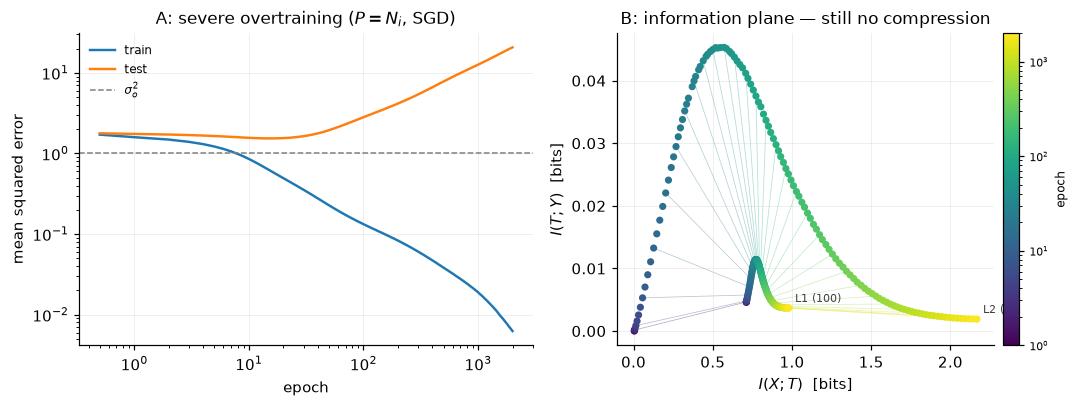

test MSE: best 1.538 @ epoch 15  ->  final 20.73   (13.5x worse)
train MSE final: 0.00626   (the training set is memorised)

                                compression   final E_g  E_g / floor  generalises?
--------------------------------------------------------------------------------
5.1  BGD, generalises            0.00000 b        1.61          1.6  yes
5.2  SGD, overfits               0.00000 b       20.30         20.3  NO

Two networks with INDISTINGUISHABLE information planes (both: monotone rise, zero
compression) and completely different generalisation. Compression cannot explain a
difference it does not have.


In [23]:
lin_of = cached("linear_sgd_overfits", lambda: run_linear(
    [100, 100, 1], dict(n_inputs=100, n_train=100, snr=1.0),
    dict(lr=0.02, n_epochs=2000, batch_size=5, n_checkpoints=100), seed=1))

fig, axes = plt.subplots(1, 2, figsize=(10.0, 3.8))
ax = axes[0]
ax.plot(np.maximum(lin_of["epochs"], 0.5), lin_of["train_mse"], label="train", color="#1f77b4")
ax.plot(np.maximum(lin_of["epochs"], 0.5), lin_of["test_mse"], label="test", color="#ff7f0e")
ax.axhline(lin_of["sigma_o"]**2, ls="--", lw=1, color="0.5", label=r"$\sigma_o^2$")
ax.set_xscale("log"); ax.set_yscale("log")
ax.set_xlabel("epoch"); ax.set_ylabel("mean squared error")
ax.set_title(r"A: severe overtraining ($P = N_i$, SGD)"); ax.legend()
plot_plane(lin_of["epochs"], lin_of["I_XT"], lin_of["I_TY"], ax=axes[1],
           title="B: information plane — still no compression",
           layer_names=lin_of["layer_names"], annotate=True)
fig.tight_layout(); save(fig, "fig10_linear_overfit"); plt.show()

best = lin_of["test_mse"].min()
print(f"test MSE: best {best:.3f} @ epoch {lin_of['epochs'][int(lin_of['test_mse'].argmin())]}"
      f"  ->  final {lin_of['test_mse'][-1]:.2f}   ({lin_of['test_mse'][-1] / best:.1f}x worse)")
print(f"train MSE final: {lin_of['train_mse'][-1]:.5f}   (the training set is memorised)")
print()
print(f"{'':30s} {'compression':>12s} {'final E_g':>11s} {'E_g / floor':>12s}  generalises?")
print("-" * 80)
for name, r in [("5.1  BGD, generalises", lin_gen), ("5.2  SGD, overfits", lin_of)]:
    comp = float((r["I_XT"].max(0) - r["I_XT"][-1]).max())
    ratio = r["E_g"][-1] / r["sigma_o"]**2
    print(f"{name:30s} {comp:>9.5f} b {r['E_g'][-1]:>11.2f} {ratio:>12.1f}"
          f"  {'yes' if ratio < 3 else 'NO'}")
print()
print("Two networks with INDISTINGUISHABLE information planes (both: monotone rise, zero")
print("compression) and completely different generalisation. Compression cannot explain a")
print("difference it does not have.")

## 5.3 The sharpest version: identical functions, different "information"

**Paper eq. (C.5).** Take a scalar two-layer linear network $\hat{y} = w_2 w_1 x$ and
rescale $\tilde{w}_1 = w_1/c$, $\tilde{w}_2 = c\,w_2$. Every member of this family computes
**exactly the same input–output map**, so they all generalise *identically*. But the hidden
activity is $h = \tilde{w}_1 x$, and once the analysis noise is added,

$$I(T;X) = \tfrac12\log\big(w_1^2/c^2 + \sigma_{MI}^2\big) - \tfrac12\log\sigma_{MI}^2,$$

which depends on $c$. Mutual information *is* invariant under invertible
reparametrisation — but $T = h + \epsilon$ is not, because the noise is injected at a fixed
scale while the representation is rescaled.

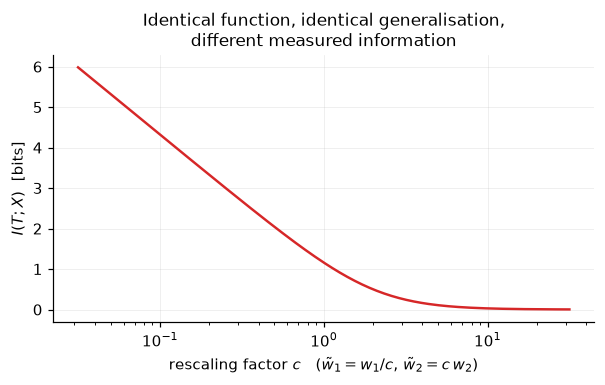

       c   w1_tilde   w2_tilde  function w2*w1   I(T;X) [bits]
--------------------------------------------------------------
    0.10     20.000      0.300           6.000           4.324
    0.50      4.000      1.500           6.000           2.044
    1.00      2.000      3.000           6.000           1.161
    2.00      1.000      6.000           6.000           0.500
   10.00      0.200     30.000           6.000           0.028

The function computed is identical in every row. The 'information' is not.


In [24]:
w1, w2 = 2.0, 3.0
cs = np.logspace(-1.5, 1.5, 200)
# a 1-input network, so mi_XT's Sigma_X = I/N_i is just 1, exactly as in eq. (C.5)
mi_c = np.array([mi_XT(np.array([[w1 / c]])) for c in cs])

fig, ax = plt.subplots(figsize=(5.6, 3.6))
ax.plot(cs, mi_c, color="#d62728")
ax.set_xscale("log")
ax.set_xlabel(r"rescaling factor $c$   ($\tilde{w}_1 = w_1/c$, $\tilde{w}_2 = c\,w_2$)")
ax.set_ylabel(r"$I(T;X)$  [bits]")
ax.set_title("Identical function, identical generalisation,\ndifferent measured information")
fig.tight_layout(); save(fig, "fig11_rescaling"); plt.show()

print(f"{'c':>8s} {'w1_tilde':>10s} {'w2_tilde':>10s} {'function w2*w1':>15s} {'I(T;X) [bits]':>15s}")
print("-" * 62)
for c in [0.1, 0.5, 1.0, 2.0, 10.0]:
    print(f"{c:8.2f} {w1/c:10.3f} {w2*c:10.3f} {w2*w1:15.3f} "
          f"{mi_XT(np.array([[w1 / c]])):15.3f}")
print()
print("The function computed is identical in every row. The 'information' is not.")

### Reading §5

1. With the estimator removed entirely, **no compression appears** — not in any layer, not
   at any depth, not under SGD or BGD.
2. So compression is not being hidden by a crude estimator. The mechanisms one might have
   hoped for (neurons becoming correlated, irrelevant input directions being projected out)
   simply do not produce it here.
3. **The dissociation.** A network that generalises well and one that overfits by an order
   of magnitude have indistinguishable information planes.
4. Eq. (C.5): networks computing *identical functions* can be assigned arbitrarily different
   $I(T;X)$. A quantity that varies while the function is fixed is not measuring a property
   of the function.

> **Claim 2 fails.** Compression does not track generalisation. Combined with §3.4 (a
> network that compresses and does *not* generalise), all four combinations of
> (compresses, generalises) are realisable.

---

# 6. Is compression caused by SGD's noise?

**Paper section 4, appendix I.**

## The claim

Shwartz-Ziv & Tishby propose a mechanism built on two phases of SGD:

* a **drift** phase, in which the mean gradient across examples is large relative to its
  standard deviation (high gradient SNR);
* a **diffusion** phase, in which the mean falls below the standard deviation (low SNR).

The argument: during diffusion the weights perform a constrained random walk whose
stationary distribution is maximum-entropy subject to a training-error constraint;
maximising that entropy maximises $H(X \mid T)$; and since $H(X)$ is fixed,
$I(X;T) = H(X) - H(X\mid T)$ is thereby minimised. Compression, on this account, is driven
by the *randomness* of SGD.

## Two independent problems

**Theoretically**, the step from "the distribution of weights *across training runs* has
maximum entropy" to "the weights of *one particular run* maximise $H(X \mid T)$" does not
follow. $H(X\mid T)$ is uncertainty about inputs given a *fixed* network; it is not
uncertainty about which network you happened to train. Different random variables.

**Empirically**, the claim makes a prediction we can test in one line: remove the
randomness. Full-batch gradient descent uses the entire training set for every update, so
it has **no sampling noise and no diffusion at all**. If compression survives, the mechanism
is wrong.

## 6.1 Full-batch gradient descent

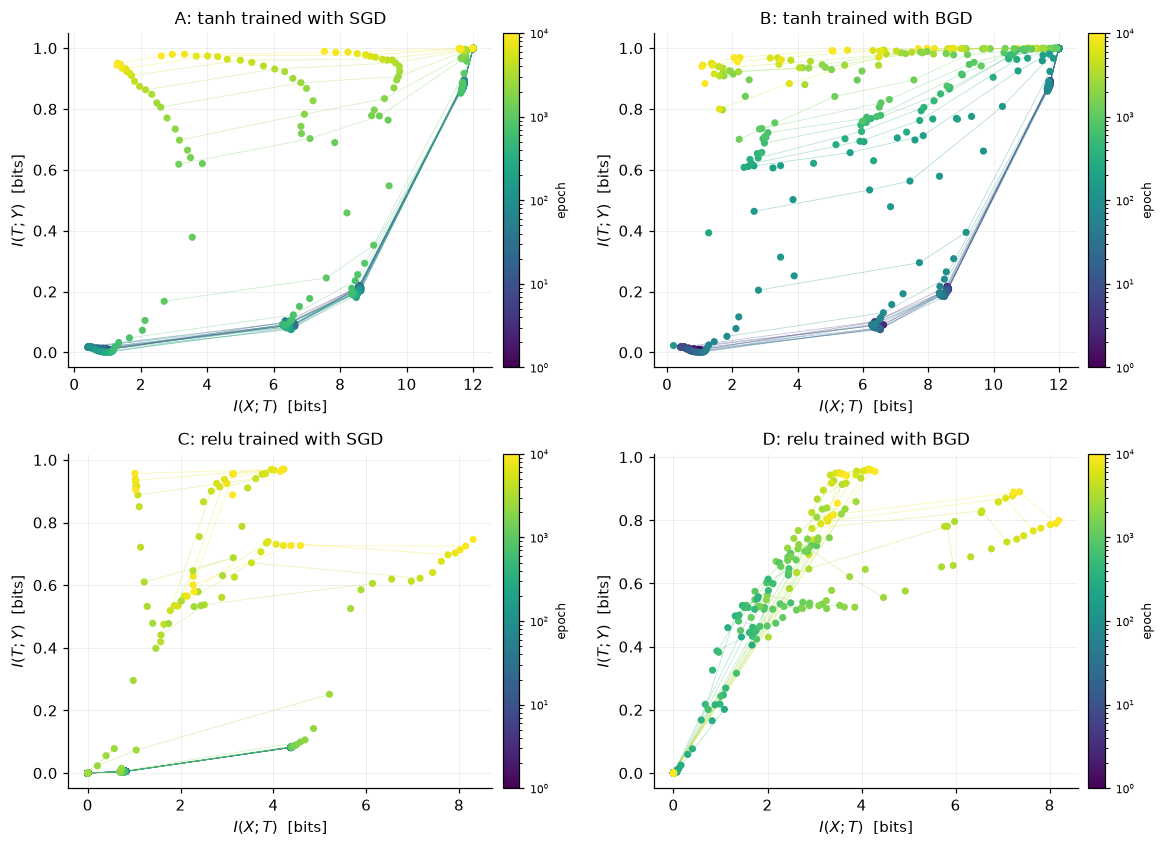

compression per layer [bits lost from peak I(X;T)]
network        L1 (10)    L2 (7)    L3 (5)    L4 (4)    L5 (3) L6 (2) out    TOTAL
----------------------------------------------------------------------------------
tanh / SGD        0.00      0.02      0.23      2.27      5.59      2.56    10.66
tanh / BGD        0.02      1.25      4.14      4.61      6.19      2.70    18.91
relu / SGD        0.00      0.00      0.00      0.02      0.08      0.37     0.47
relu / BGD        0.00      0.13      0.00      0.00      0.00      0.00     0.13

tanh : SGD  10.66 bits   vs   BGD  18.91 bits
relu : SGD   0.47 bits   vs   BGD   0.13 bits

Batch gradient descent is completely deterministic -- same data, same update, every
epoch, no sampling noise anywhere. tanh compresses just as much, in fact MORE.


In [25]:
log_tanh_bgd = cached("mlp_tanh_bgd",
                      lambda: train_mlp(activation="tanh", batch_size=None, lr=0.5))
log_relu_bgd = cached("mlp_relu_bgd",
                      lambda: train_mlp(activation="relu", batch_size=None, lr=0.5))

relu_bgd_lo = min(float(a.min()) for acts in log_relu_bgd["activations"] for a in acts)
relu_bgd_hi = max(float(a.max()) for acts in log_relu_bgd["activations"] for a in acts)

plane_tanh_bgd = cached("plane_tanh_bgd", lambda: information_plane(
    log_tanh_bgd["activations"], y_all, n_bins=30, bounds=(-1.0, 1.0)))
plane_relu_bgd = cached("plane_relu_bgd", lambda: information_plane(
    log_relu_bgd["activations"], y_all, n_bins=100, bounds=(relu_bgd_lo, relu_bgd_hi)))

runs = [("tanh", "SGD", log_tanh, plane_tanh), ("tanh", "BGD", log_tanh_bgd, plane_tanh_bgd),
        ("relu", "SGD", log_relu, plane_relu), ("relu", "BGD", log_relu_bgd, plane_relu_bgd)]

fig, axes = plt.subplots(2, 2, figsize=(10.8, 7.8))
for ax, (act, opt, lg, (ixt, ity)), panel in zip(axes.ravel(), runs, "ABCD"):
    plot_plane(lg["epochs"], ixt, ity, ax=ax,
               title=f"{panel}: {act} trained with {opt}", layer_names=lg["layer_names"])
fig.tight_layout(); save(fig, "fig12_sgd_vs_bgd"); plt.show()

print("compression per layer [bits lost from peak I(X;T)]")
print(f"{'network':12s} " + " ".join(f"{n:>9s}" for n in log_tanh['layer_names']) + f" {'TOTAL':>8s}")
print("-" * 82)
for act, opt, lg, (ixt, _) in runs:
    c = ixt.max(0) - ixt[-1]
    print(f"{act + ' / ' + opt:12s} " + " ".join(f"{v:>9.2f}" for v in c) + f" {c.sum():>8.2f}")
print()
for act in ("tanh", "relu"):
    s = next(ixt.max(0) - ixt[-1] for a, o, _, (ixt, _) in runs if a == act and o == "SGD").sum()
    b = next(ixt.max(0) - ixt[-1] for a, o, _, (ixt, _) in runs if a == act and o == "BGD").sum()
    print(f"{act:5s}: SGD {s:6.2f} bits   vs   BGD {b:6.2f} bits")
print()
print("Batch gradient descent is completely deterministic -- same data, same update, every")
print("epoch, no sampling noise anywhere. tanh compresses just as much, in fact MORE.")

## 6.2 The gradient-SNR transition happens where compression is impossible

The drift $\to$ diffusion transition is a real phenomenon — measure it and it is plainly
there. Per layer (paper eqs I.1–I.2),

$$m_l = \big\|\langle \partial E/\partial W_l\rangle\big\|_F, \qquad
  s_l = \big\|\mathrm{STD}(\partial E/\partial W_l)\big\|_F, \qquad
  \mathrm{SNR}_l = m_l/s_l,$$

with mean and element-wise standard deviation taken across training examples.

The question is not whether the transition exists, but whether it is *tied to compression*.
So construct the cleanest possible test: a linear network with a **single** hidden unit
($1$–$1$–$1$) and small initial weights. With one hidden unit whose weight only grows, there
is no room for $I(X;T)$ to fall — **compression is ruled out by construction**. If the SNR
transition still appears, it is conclusively independent of compression.

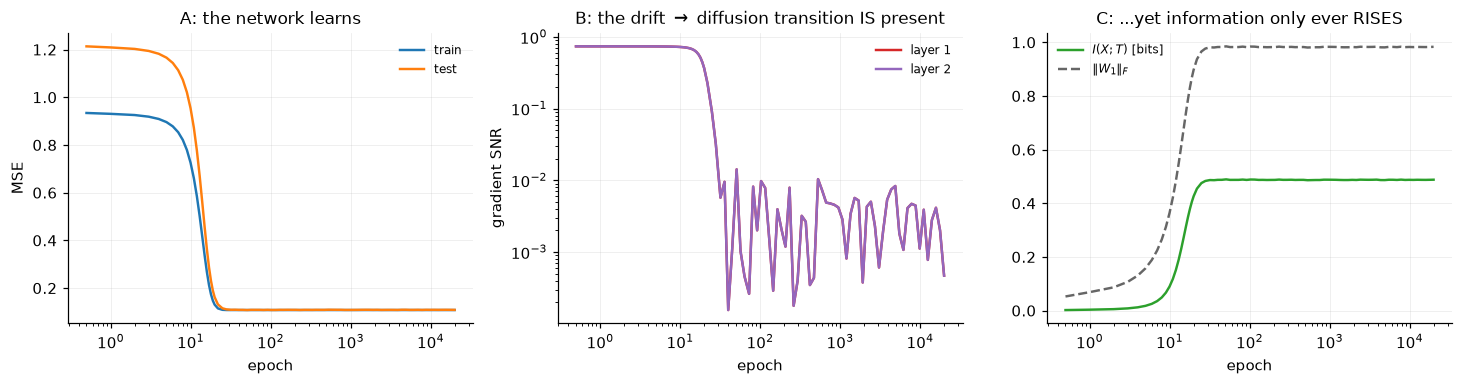

gradient SNR : 0.738 -> 1.55e-04   (4,760x drop)
||W_1||_F    : 0.0527 -> 0.9832   (grows)
I(X;T)       : 0.0020 -> 0.4879 bits   (a RISE of 0.4859)
             : largest drawdown below its own peak 0.00125 bits -- SGD jitter, 389x
               smaller than the rise. There is no compression here to explain.

So: a 1000x+ collapse in gradient SNR alongside information that only ever goes UP.
The drift -> diffusion transition is real and has nothing to do with compression.


In [26]:
lin_min = cached("linear_1_1_1_snr", lambda: run_linear(
    [1, 1, 1], dict(n_inputs=1, n_train=100, snr=10.0),
    dict(lr=0.001, n_epochs=20000, batch_size=1, n_checkpoints=60, init_std=0.05), seed=6))

fig, axes = plt.subplots(1, 3, figsize=(13.4, 3.6))
x = np.maximum(lin_min["epochs"], 0.5)

axes[0].plot(x, lin_min["train_mse"], label="train", color="#1f77b4")
axes[0].plot(x, lin_min["test_mse"], label="test", color="#ff7f0e")
axes[0].set_xscale("log"); axes[0].set_xlabel("epoch"); axes[0].set_ylabel("MSE")
axes[0].set_title("A: the network learns"); axes[0].legend()

axes[1].plot(x, lin_min["grad_snr"][:, 0], color="#d62728", label="layer 1")
axes[1].plot(x, lin_min["grad_snr"][:, 1], color="#9467bd", label="layer 2")
axes[1].set_xscale("log"); axes[1].set_yscale("log")
axes[1].set_xlabel("epoch"); axes[1].set_ylabel("gradient SNR")
axes[1].set_title(r"B: the drift $\to$ diffusion transition IS present"); axes[1].legend()

axes[2].plot(x, lin_min["I_XT"][:, 0], color="#2ca02c", label=r"$I(X;T)$ [bits]")
axes[2].plot(x, lin_min["weight_norms"][:, 0], color="0.4", ls="--", label=r"$\|W_1\|_F$")
axes[2].set_xscale("log"); axes[2].set_xlabel("epoch")
axes[2].set_title("C: ...yet information only ever RISES"); axes[2].legend()

fig.tight_layout(); save(fig, "fig13_snr_without_compression"); plt.show()

snr = lin_min["grad_snr"][:, 0]
ixt_min = lin_min["I_XT"][:, 0]
print(f"gradient SNR : {np.nanmax(snr):.3f} -> {np.nanmin(snr):.2e}   "
      f"({np.nanmax(snr) / max(np.nanmin(snr), 1e-15):,.0f}x drop)")
print(f"||W_1||_F    : {lin_min['weight_norms'][0,0]:.4f} -> {lin_min['weight_norms'][-1,0]:.4f}   (grows)")
print(f"I(X;T)       : {ixt_min[0]:.4f} -> {ixt_min[-1]:.4f} bits   "
      f"(a RISE of {ixt_min[-1] - ixt_min[0]:.4f})")
draw = ixt_min.max() - ixt_min[-1]
print(f"             : largest drawdown below its own peak {draw:.5f} bits -- SGD jitter, "
      f"{(ixt_min[-1] - ixt_min[0]) / max(draw, 1e-12):.0f}x")
print(f"               smaller than the rise. There is no compression here to explain.")
print()
print("So: a 1000x+ collapse in gradient SNR alongside information that only ever goes UP.")
print("The drift -> diffusion transition is real and has nothing to do with compression.")

### Why the transition is generic

Weights start small, so early in training *every* sample agrees they should grow — a large,
consistent mean gradient, hence high SNR. Near a minimum the mean gradient goes to zero **by
the definition of a minimum**, while the per-sample standard deviation stays finite, because
individual examples still disagree about which direction would help them. So $m_l/s_l$
collapses at convergence in *any* setting whatsoever.

This was described long before the IB literature, as the transient/stochastic phases (Murata
1998) or search/convergence phases (Chee & Toulis 2017). It is a property of arriving at a
minimum, not of compressing a representation.

> **Claim 3 fails.** Compression survives the complete removal of stochasticity, and the SNR
> transition appears in a network where compression is impossible.

---

# 7. When compression *is* real — is it a second phase?

**Paper section 5, figure 6.**

Sections 3–6 dismantled three claims, but a nagging intuition survives all of them:

> If some input channels carry nothing but noise, surely good generalisation *requires*
> throwing them away. Isn't that compression, and isn't it necessary?

The intuition is sound, and the paper takes it seriously by constructing its cleanest
version: split the input into a **task-relevant** and a **task-irrelevant** block, with the
teacher's weights on the irrelevant block set to exactly zero.

$$X = [\,X_{\mathrm{rel}}\ \ X_{\mathrm{irrel}}\,], \qquad
  Y = W_o^{\mathrm{rel}} X_{\mathrm{rel}} + \epsilon_o, \qquad W_o^{\mathrm{irrel}} = 0.$$

$X_{\mathrm{irrel}}$ is pure nuisance by construction; a network that generalises **must**
end up ignoring it. Two separate questions follow:

1. Does $I(X_{\mathrm{irrel}};T)$ decrease?
2. Does it decrease **after** fitting finishes (a second phase), or **at the same time**?

Everything is exact — a linear network, so eq. (6) and the subspace formula give true values.

## Measuring information about a subspace

For $T = \bar{W}X + \epsilon_{MI}$, conditioning on one block leaves the other acting as
extra noise. With $S$ the block of interest and $\bar S$ its complement,

$$I(T; X_S) = \underbrace{\tfrac12\log\big|\bar{W}\Sigma_X\bar{W}^\top + \sigma_{MI}^2 I\big|}_{H(T)}
 - \underbrace{\tfrac12\log\big|\bar{W}_{\bar S}\Sigma_{\bar S}\bar{W}_{\bar S}^\top + \sigma_{MI}^2 I\big|}_{H(T\mid X_S)}$$

— implemented above as `mi_subspace`. This is a genuine mutual information, not a proxy,
which is what makes the answer sharp.

In [27]:
def run_relevance(n_relevant=30, n_irrelevant=70, n_train=1000, snr=5.0,
                  lr=0.05, n_epochs=3000, batch_size=5, seed=0):
    n_in = n_relevant + n_irrelevant
    prob = make_teacher(n_inputs=n_in, n_train=n_train, snr=snr,
                        n_relevant=n_relevant, seed=seed)
    net = LinearNet([n_in, 100, 1], init_std=0.03, seed=seed)
    lg = train_linear(net, prob, lr=lr, n_epochs=n_epochs, batch_size=batch_size,
                      n_checkpoints=60, seed=seed)
    H = 0                                   # the hidden layer
    maps = [m[H] for m in lg["layer_maps"]]
    lg["I_XT"] = np.array([mi_XT(W) for W in maps])
    lg["I_rel"] = np.array([mi_subspace(W, slice(0, n_relevant)) for W in maps])
    lg["I_irr"] = np.array([mi_subspace(W, slice(n_relevant, n_in)) for W in maps])
    lg["I_TY"] = np.array([mi_TY(W, prob["W_o"], prob["sigma_o"]) for W in maps])
    lg["E_g"] = np.array([gen_error(m[-1], prob["W_o"], prob["sigma_o"])
                          for m in lg["layer_maps"]])
    lg["sigma_o"] = prob["sigma_o"]
    return lg

rel = cached("relevance_seed0", lambda: run_relevance(seed=0))

print(f"input     : 30 task-relevant + 70 task-irrelevant dimensions")
print(f"training  : P = 1000, SGD with 5 samples/batch, 3000 epochs, teacher SNR = 5")
print(f"test MSE  : {rel['test_mse'][0]:.3f} -> {rel['test_mse'][-1]:.3f}"
      f"   (irreducible floor {rel['sigma_o']**2:.3f})")
print(f"exact E_g : {rel['E_g'][0]:.3f} -> {rel['E_g'][-1]:.3f}")
print(f"I(T;Y)    : {rel['I_TY'][0]:.4f} -> {rel['I_TY'][-1]:.4f} bits   (it learns the task)")

input     : 30 task-relevant + 70 task-irrelevant dimensions
training  : P = 1000, SGD with 5 samples/batch, 3000 epochs, teacher SNR = 5
test MSE  : 0.390 -> 0.211   (irreducible floor 0.200)
exact E_g : 0.400 -> 0.215
I(T;Y)    : 0.0005 -> 0.1107 bits   (it learns the task)


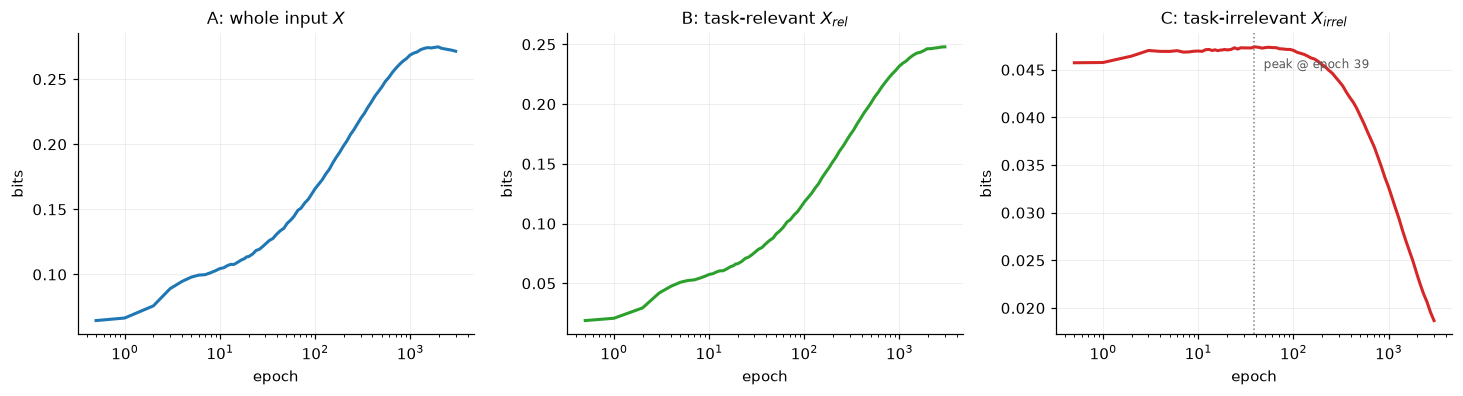

A: whole input $X$                0.065 ->  0.271 bits   peak  0.275 @ epoch  1962   no compression
B: task-relevant $X_{rel}$        0.019 ->  0.248 bits   peak  0.248 @ epoch  3000   no compression
C: task-irrelevant $X_{irrel}$    0.046 ->  0.019 bits   peak  0.047 @ epoch    39   COMPRESSES


In [28]:
fig, axes = plt.subplots(1, 3, figsize=(13.4, 3.7))
x = np.maximum(rel["epochs"], 0.5)
panels = [("A: whole input $X$", rel["I_XT"], "#1f77b4"),
          ("B: task-relevant $X_{rel}$", rel["I_rel"], "#2ca02c"),
          ("C: task-irrelevant $X_{irrel}$", rel["I_irr"], "#d62728")]
for ax, (title, y, c) in zip(axes, panels):
    ax.plot(x, y, color=c, lw=2)
    ax.set_xscale("log"); ax.set_xlabel("epoch"); ax.set_ylabel("bits"); ax.set_title(title)
    pk = int(np.argmax(y))
    if y.max() - y[-1] > 0.01:
        ax.axvline(x[pk], ls=":", color="0.5", lw=1)
        ax.annotate(f"peak @ epoch {rel['epochs'][pk]}", (x[pk], y[pk]),
                    textcoords="offset points", xytext=(6, -14), fontsize=8, color="0.35")
fig.tight_layout(); save(fig, "fig14_relevant_irrelevant"); plt.show()

for title, y, _ in panels:
    verdict = "COMPRESSES" if y.max() - y[-1] > 0.01 else "no compression"
    print(f"{title:32s} {y[0]:6.3f} -> {y[-1]:6.3f} bits   peak {y.max():6.3f} "
          f"@ epoch {rel['epochs'][int(np.argmax(y))]:5d}   {verdict}")

So the intuition is **half** right:

* **Panel A** — information about the input *as a whole* does not compress. Anyone watching
  only $I(X;T)$, as the standard information plane does, would conclude nothing was
  discarded.
* **Panel B** — information about the relevant subspace rises robustly. That is fitting.
* **Panel C** — information about the irrelevant subspace rises and then **falls**. Genuine
  compression of genuinely irrelevant information.

Panel C is a real effect, and it is invisible in panel A. Now the timing question.

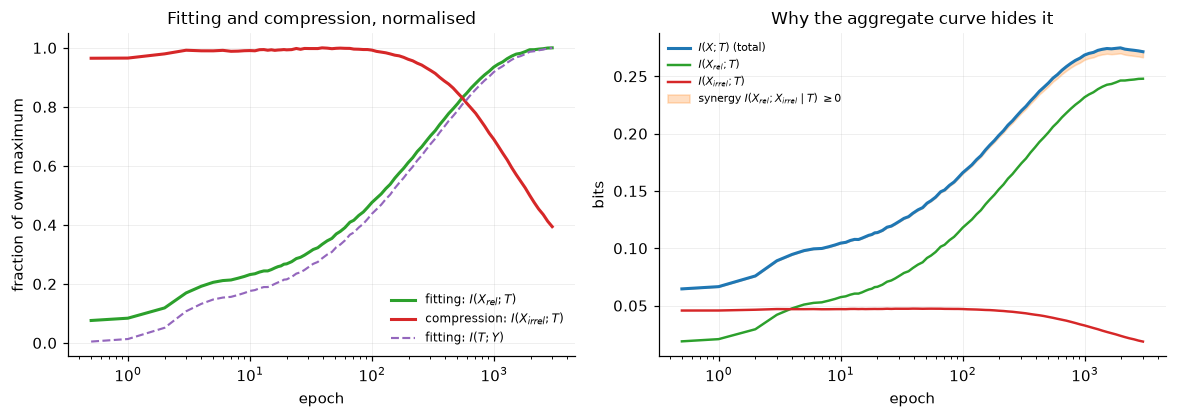

compression of X_irrel begins (its peak)      : epoch 39
I(X_rel;T) reaches 50% of its total rise      : epoch 154
I(X_rel;T) reaches 90% of its total rise      : epoch 839

When compression BEGINS, fitting is only 28% complete.
=> the two processes are INTERLEAVED, not sequential. No separate second phase.

minimum synergy over training : +0.00001 bits  (must be >= 0)
The synergy term absorbs the difference, which is how I(X;T) can rise while
I(X_irrel;T) falls. Watching only I(X;T) tells you nothing about either part.


In [29]:
fig, axes = plt.subplots(1, 2, figsize=(10.8, 3.9))

ax = axes[0]
ax.plot(x, rel["I_rel"] / rel["I_rel"].max(), color="#2ca02c", lw=2,
        label=r"fitting: $I(X_{rel};T)$")
ax.plot(x, rel["I_irr"] / rel["I_irr"].max(), color="#d62728", lw=2,
        label=r"compression: $I(X_{irrel};T)$")
ax.plot(x, rel["I_TY"] / rel["I_TY"].max(), color="#9467bd", lw=1.4, ls="--",
        label=r"fitting: $I(T;Y)$")
ax.set_xscale("log"); ax.set_xlabel("epoch"); ax.set_ylabel("fraction of own maximum")
ax.set_title("Fitting and compression, normalised"); ax.legend(loc="lower right")

ax = axes[1]
synergy = rel["I_XT"] - (rel["I_rel"] + rel["I_irr"])
ax.plot(x, rel["I_XT"], color="#1f77b4", lw=2, label=r"$I(X;T)$ (total)")
ax.plot(x, rel["I_rel"], color="#2ca02c", lw=1.6, label=r"$I(X_{rel};T)$")
ax.plot(x, rel["I_irr"], color="#d62728", lw=1.6, label=r"$I(X_{irrel};T)$")
ax.fill_between(x, rel["I_rel"] + rel["I_irr"], rel["I_XT"], color="#ff7f0e", alpha=0.25,
                label=r"synergy $I(X_{rel};X_{irrel}\mid T)\ \geq 0$")
ax.set_xscale("log"); ax.set_xlabel("epoch"); ax.set_ylabel("bits")
ax.set_title("Why the aggregate curve hides it"); ax.legend(fontsize=7)

fig.tight_layout(); save(fig, "fig15_timing_and_synergy"); plt.show()

pk = int(np.argmax(rel["I_irr"]))
frac_done = (rel["I_rel"][pk] - rel["I_rel"][0]) / (rel["I_rel"][-1] - rel["I_rel"][0])
z = (rel["I_rel"] - rel["I_rel"].min()) / np.ptp(rel["I_rel"])
print(f"compression of X_irrel begins (its peak)      : epoch {rel['epochs'][pk]}")
print(f"I(X_rel;T) reaches 50% of its total rise      : epoch {rel['epochs'][int(np.argmax(z >= 0.5))]}")
print(f"I(X_rel;T) reaches 90% of its total rise      : epoch {rel['epochs'][int(np.argmax(z >= 0.9))]}")
print()
print(f"When compression BEGINS, fitting is only {100 * frac_done:.0f}% complete.")
print(f"=> the two processes are INTERLEAVED, not sequential. No separate second phase.")
print()
print(f"minimum synergy over training : {synergy.min():+.5f} bits  (must be >= 0)")
print("The synergy term absorbs the difference, which is how I(X;T) can rise while")
print("I(X_irrel;T) falls. Watching only I(X;T) tells you nothing about either part.")

In [30]:
print("robustness across seeds")
print(f"{'seed':>5s} {'I(X;T) drop':>13s} {'I(X_rel;T) rise':>17s} {'I(X_irr;T) drop':>17s} "
      f"{'fitting % done':>16s}")
print("-" * 74)
for s in (0, 1, 2):
    r = cached(f"relevance_seed{s}", lambda s=s: run_relevance(seed=s))
    p = int(np.argmax(r["I_irr"]))
    done = 100 * (r["I_rel"][p] - r["I_rel"][0]) / max(r["I_rel"][-1] - r["I_rel"][0], 1e-12)
    print(f"{s:>5d} {r['I_XT'].max() - r['I_XT'][-1]:>13.3f} "
          f"{r['I_rel'][-1] - r['I_rel'][0]:>+17.3f} "
          f"{r['I_irr'].max() - r['I_irr'][-1]:>17.3f} {done:>15.0f}%")

robustness across seeds
 seed   I(X;T) drop   I(X_rel;T) rise   I(X_irr;T) drop   fitting % done
--------------------------------------------------------------------------
    0         0.003            +0.229             0.029              28%


    1         0.004            +0.239             0.027              40%
    2         0.001            +0.279             0.028              12%


---

# 8. Summary

## The three claims, and what we measured

| claim | test | result |
|---|---|---|
| **1. Training has two phases, the second being compression** | replace `tanh` with `relu`, change nothing else (§3) | tanh compresses ~11 bits; ReLU ~0.5, and only in its sigmoidal output layer, with equal test accuracy. **Not general.** |
| **2. Compression causes generalisation** | exact MI in deep linear nets (§5); tanh on 30% data (§3.4) | networks that generalise well never compress; a network that overfits compresses heavily; two nets with identical planes differ 13× in $E_g$. **No relationship.** |
| **3. Compression is driven by SGD's diffusion** | deterministic full-batch GD (§6.1); a $1$–$1$–$1$ net where compression is impossible (§6.2) | BGD compresses *more* than SGD; the SNR transition appears, dropping $4{,}800\times$, where $I(X;T)$ can only rise. **Wrong mechanism.** |

## And the deeper point

For a deterministic network, $I(X;T)$ is $\infty$ (continuous $X$) or constant (discrete
$X$). Every finite number in an information plane comes from an assumption the analyst
added — a binning scheme or an injected noise level — and §4 showed that **holding the
network fixed and changing only that assumption flips the conclusion**:

* bins uniform in activation → the tanh network compresses;
* bins uniform in net input → the same weights, no compression;
* bins at machine precision → a flat line at $\log_2 P$, no dynamics at all.

## What survives

Not nothing, and this is worth stating clearly:

* **The saturation phenomenon is real.** tanh units really do migrate into their asymptotes
  as weights grow (§3.3). What is in dispute is whether "the layer discarded 10 bits about
  the input" is a fair description of that.
* **Task-irrelevant information really is compressed** (§7) — but *concurrently* with
  fitting, not in a second phase, and it is invisible in $I(X;T)$, so the standard
  information plane is the wrong instrument for seeing it.
* **The drift → diffusion transition is real** (§6.2). It is a generic property of
  converging to a minimum, and was described decades before the IB literature.

## If you want to use information theory on a network anyway

1. State the assumption that makes $I(X;T)$ finite, and report it as a parameter of the
   measurement, not of the network.
2. Check that your conclusion survives changing it (bin count, bin placement, noise level).
3. Prefer settings where the quantity is exact (linear-Gaussian) or where the input alphabet
   is finite and fully enumerated (as here).
4. If the question is about *what* is discarded, measure subspaces (§7), not the aggregate.

---

## Where to go deeper

This notebook is the argument end to end. The project's research notebooks go further on
each piece — more estimators, more activations, more seeds, and the experiments that did not
fit a linear narrative.

| section here | deep dive | what it adds |
|---|---|---|
| §2 minimal model | [`../notebooks/01_minimal_model.ipynb`](../notebooks/01_minimal_model.ipynb) | sigmoid and softplus too; figure C1's far-field behaviour |
| §3 replication | [`../notebooks/02_tishby_replication.ipynb`](../notebooks/02_tishby_replication.ipynb) | Kolchinsky–Tracey KDE bounds across 4 activations, averaged over 5 seeds; appendix E activation histograms |
| §4 measurement | [`../notebooks/02_tishby_replication.ipynb`](../notebooks/02_tishby_replication.ipynb) §2.4–2.5 | the same estimator comparison at greater length |
| §5 linear networks | [`../notebooks/03_linear_networks.ipynb`](../notebooks/03_linear_networks.ipynb) | five hidden layers (fig. F1), a 20 000-epoch run past the paper's window, figure H1 |
| §6 SGD vs BGD | [`../notebooks/04_sgd_vs_bgd.ipynb`](../notebooks/04_sgd_vs_bgd.ipynb) | full gradient-SNR panels for the *real* network, not just the 1–1–1 model |
| §7 relevant/irrelevant | [`../notebooks/05_simultaneous_fitting.ipynb`](../notebooks/05_simultaneous_fitting.ipynb) | the sub-additivity identity and synergy term in detail |
| *not covered here* | [`../notebooks/06_mnist_kde.ipynb`](../notebooks/06_mnist_kde.ipynb) | **MNIST**, 784–1024–20–20–20–10, KDE bounds at scale (paper figs. 1C–D, B2–B3) |

The estimators themselves live in `../ibdl/estimators/` and are validated against the
original authors' code to relative $10^{-10}$ by `../tests/test_estimators.py`.

---

## Continue

**[`2_transformer_extension.ipynb`](2_transformer_extension.ipynb)** — beyond the paper.
Saxe et al. tested nonlinearities. A transformer contains two *bounded* operations they
never examined — **softmax attention** and **LayerNorm** — and their own mechanism predicts
that a transformer should compress for a reason that has nothing to do with its activation
function. We test that, and it holds.

## References

* A. M. Saxe et al., *On the information bottleneck theory of deep learning*, ICLR 2018;
  J. Stat. Mech. (2019) 124020.
* R. Shwartz-Ziv & N. Tishby, *Opening the black box of deep neural networks via
  information*, arXiv:1703.00810 (2017).
* N. Tishby & N. Zaslavsky, *Deep learning and the information bottleneck principle*,
  ITW 2015.
* A. M. Saxe, J. L. McClelland & S. Ganguli, *Exact solutions to the nonlinear dynamics of
  learning in deep linear neural networks*, ICLR 2014.
* M. S. Advani & A. M. Saxe, *High-dimensional dynamics of generalization error in neural
  networks*, arXiv:1710.03667 (2017).
* A. Kolchinsky & B. D. Tracey, *Estimating mixture entropy with pairwise distances*,
  Entropy 19(7):361 (2017).
* N. Murata, *A statistical study of on-line learning*, in *Online Learning and Neural
  Networks* (1998).